In [70]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [71]:
results = pd.read_csv('data/results.csv')
drivers = pd.read_csv('data/drivers.csv')
constructors = pd.read_csv('data/constructors.csv')
races = pd.read_csv('data/races.csv')

Ile razy kierowca jechał dla danego zespołu.

In [72]:
driver_constructor_counts = results.groupby(['driverId', 'constructorId']).size().reset_index(name='weight')

In [73]:
drivers['name'] = drivers['forename'] + ' ' + drivers['surname']
driver_id_to_name = dict(zip(drivers['driverId'], drivers['name']))
constructor_id_to_name = dict(zip(constructors['constructorId'], constructors['name']))

In [74]:
B = nx.Graph()

Kierowcy (bipartite = 0)

In [75]:
for driver_id in driver_constructor_counts['driverId'].unique():
    B.add_node(f'd_{driver_id}', 
               label=driver_id_to_name.get(driver_id, f'Driver {driver_id}'), 
               bipartite=0)

Zespoły (bipartite = 1)

In [76]:
for constructor_id in driver_constructor_counts['constructorId'].unique():
    B.add_node(f'c_{constructor_id}', 
               label=constructor_id_to_name.get(constructor_id, f'Team {constructor_id}'), 
               bipartite=1)

In [77]:
for _, row in driver_constructor_counts.iterrows():
    B.add_edge(f'd_{row["driverId"]}', f'c_{row["constructorId"]}', weight=row['weight'])

In [78]:
edges_data = [{
    'driver_id': row['driverId'],
    'driver_name': driver_id_to_name.get(row['driverId'], ''),
    'constructor_id': row['constructorId'],
    'constructor_name': constructor_id_to_name.get(row['constructorId'], ''),
    'weight': row['weight']
} for _, row in driver_constructor_counts.iterrows()]

In [79]:
edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('driver_team_edges.csv', index=False)

Zapis do formatu graphml

In [80]:
nx.write_graphml(B, 'driver_team_graph.graphml')

Wizualizacja grafu

C:\Users\micha\AppData\Local\Temp\ipykernel_11316\1169749433.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


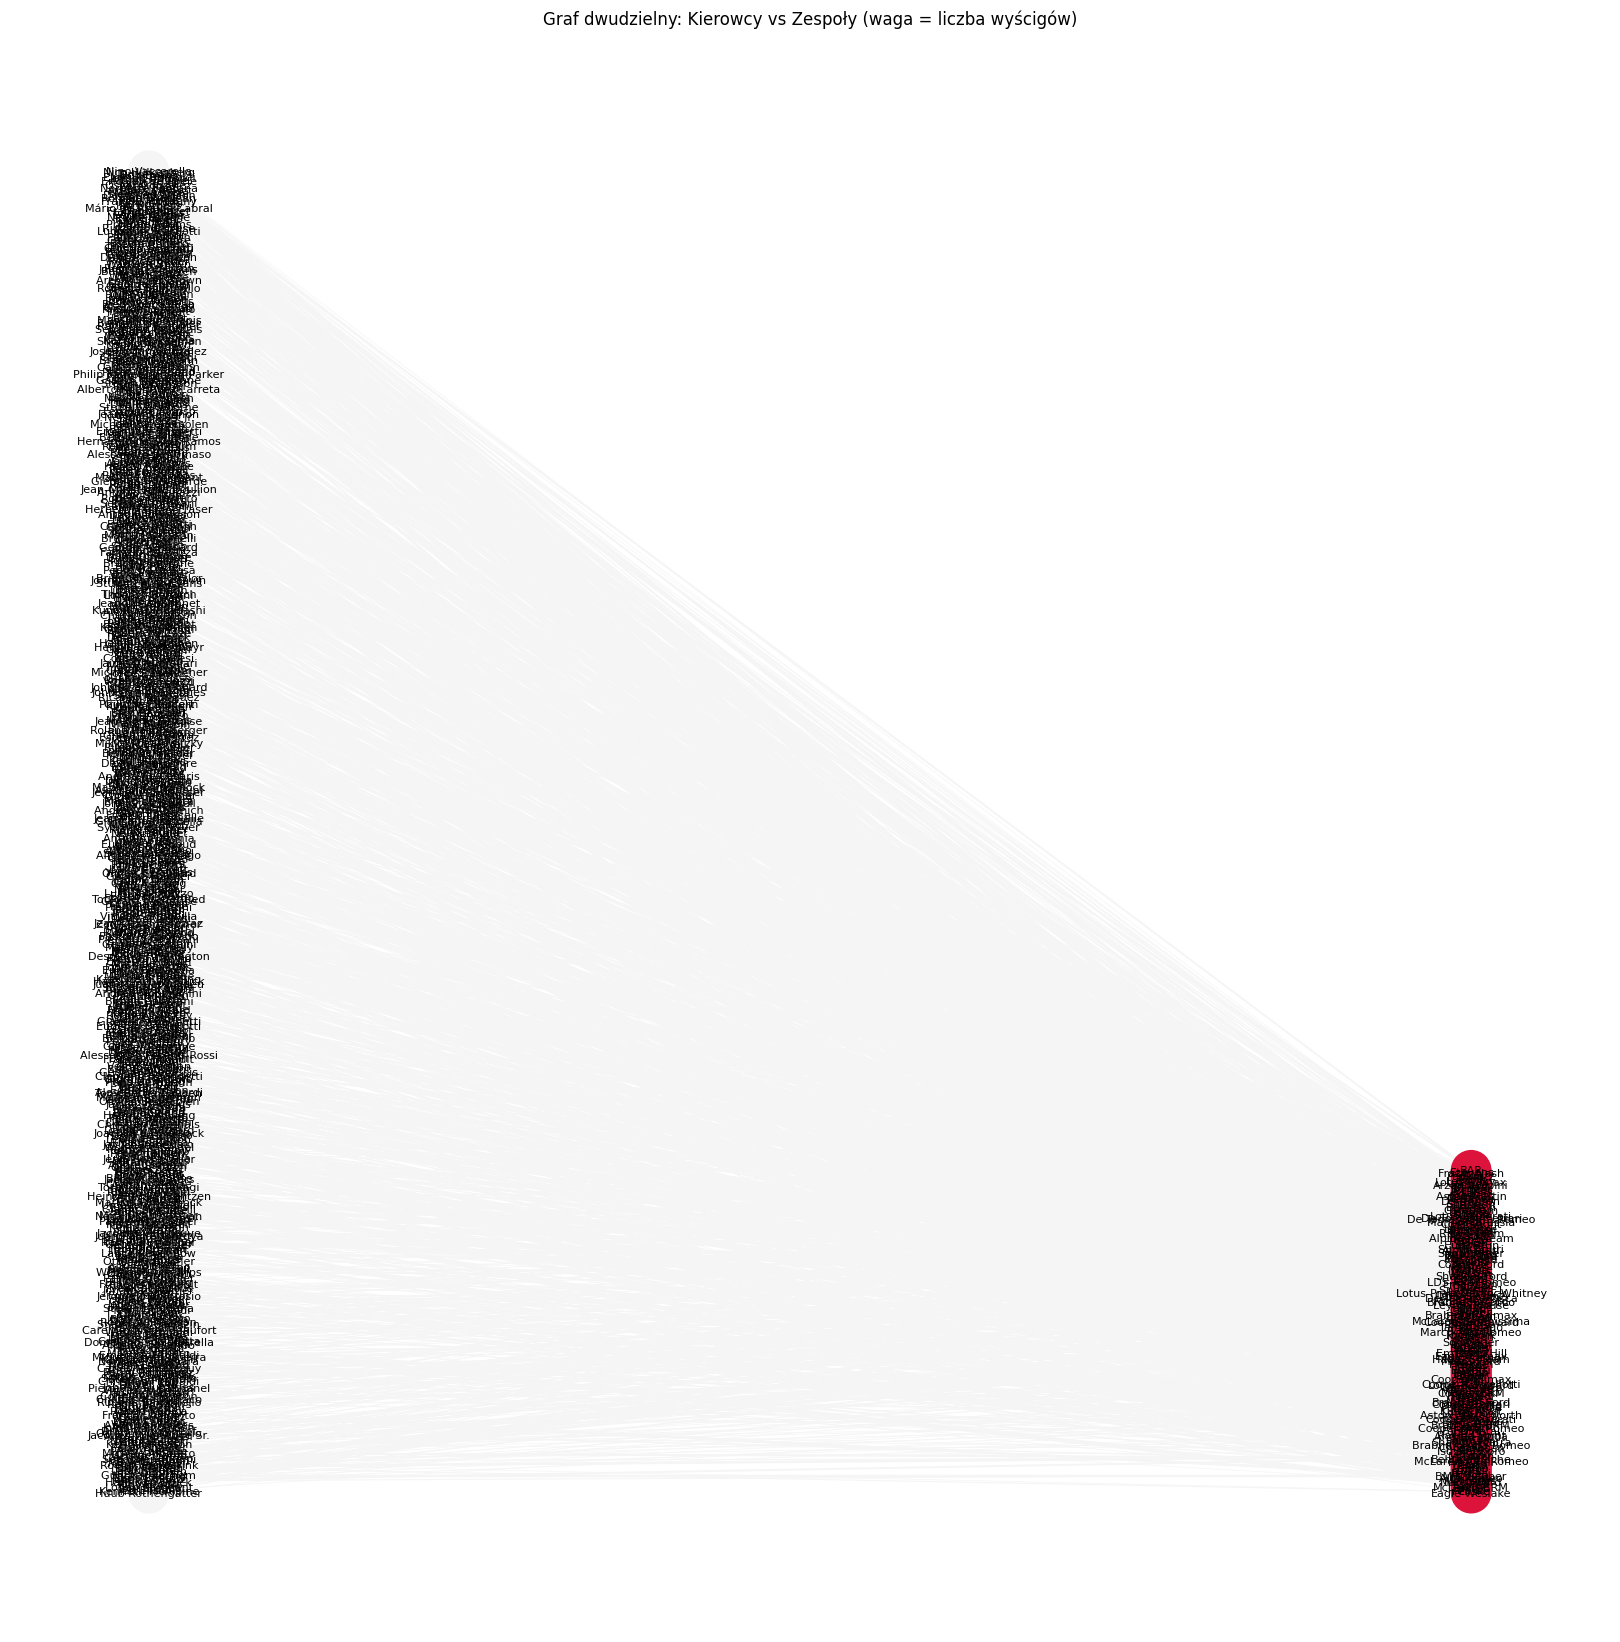

In [81]:
drivers_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
teams_nodes = set(B) - drivers_nodes

pos = dict()
pos.update((node, (1, i)) for i, node in enumerate(drivers_nodes))  # lewa strona
pos.update((node, (2, i)) for i, node in enumerate(teams_nodes))    # prawa strona

weights = [d['weight'] for _, _, d in B.edges(data=True)]
min_w = min(weights)
max_w = max(weights)

edge_weights = [0.5 + 4.5 * (w - min_w) / (max_w - min_w) for w in weights]

plt.figure(figsize=(16, 16))
nx.draw(
    B, pos,
    with_labels=True,
    labels=nx.get_node_attributes(B, 'label'),
    node_color=['whitesmoke' if n in drivers_nodes else 'crimson' for n in B.nodes()],
    edge_color='whitesmoke',
    node_size=800,
    width=edge_weights,
    font_size=8
)
plt.title("Graf dwudzielny: Kierowcy vs Zespoły (waga = liczba wyścigów)")
plt.axis('off')
plt.tight_layout()
plt.savefig('1.png', dpi=300, facecolor='gray')
plt.show()

Wybranie tylko niektórych wierzchołków dla poszczególnych wag krawędzi.

In [82]:
min_weight = 30

C:\Users\micha\AppData\Local\Temp\ipykernel_11316\687990803.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


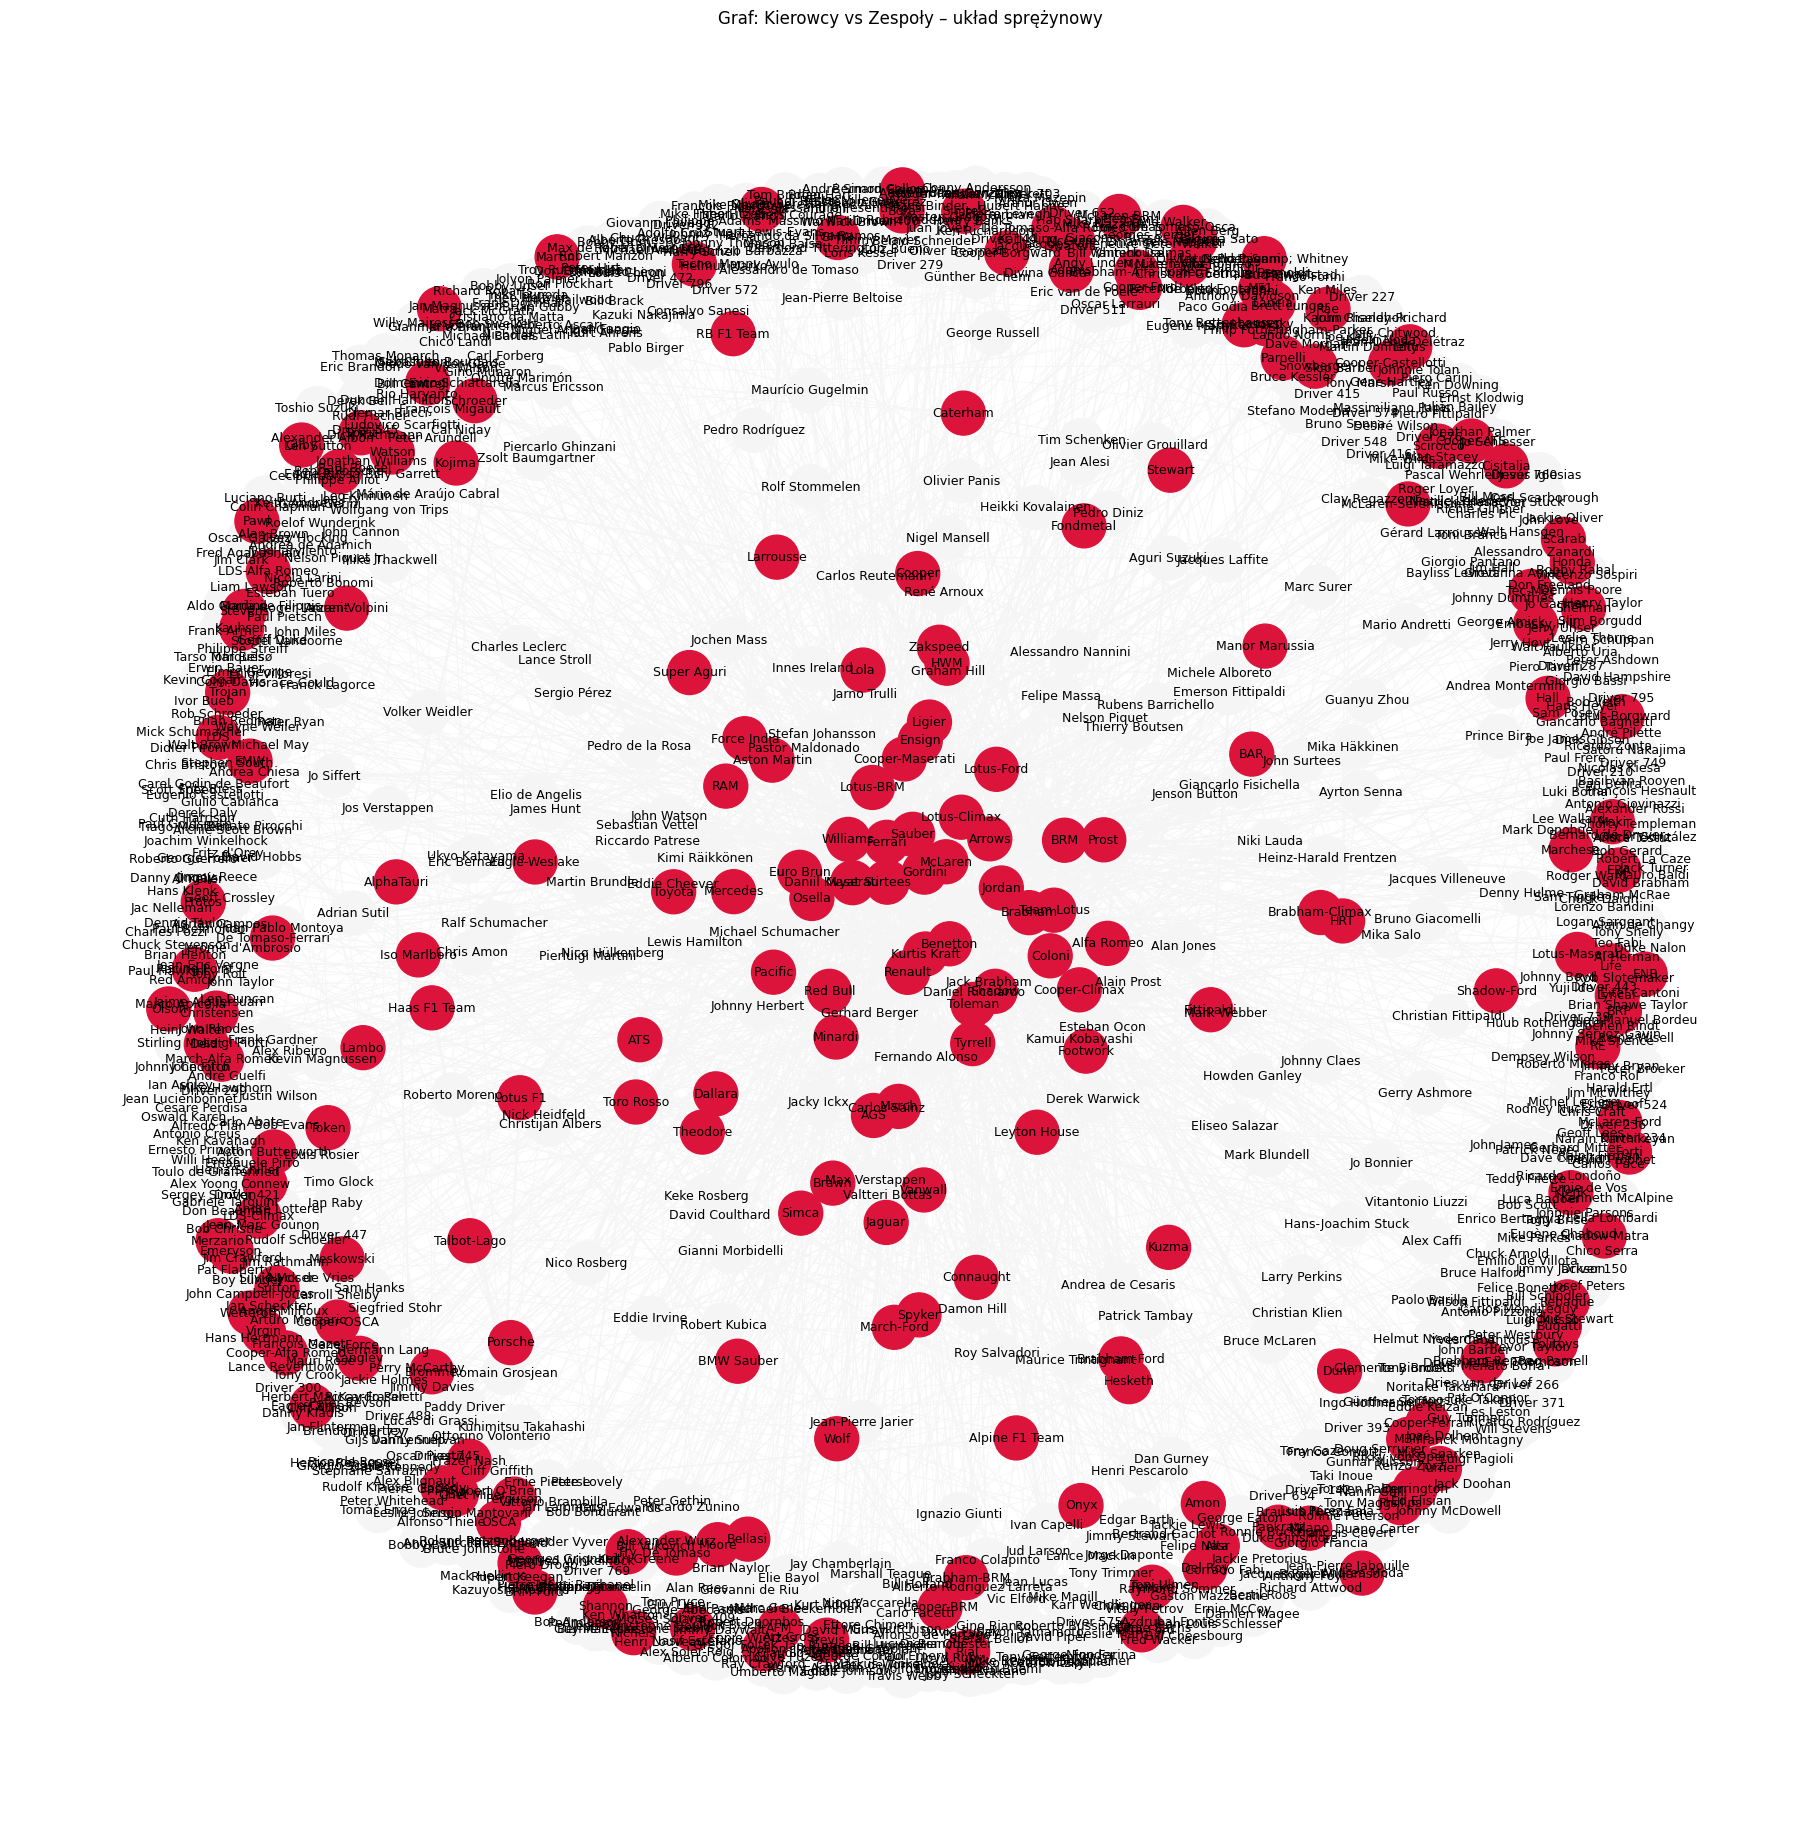

In [83]:
pos = nx.spring_layout(B, seed=1, k=1.41)  
pos1 = pos

weights = [d['weight'] for _, _, d in B.edges(data=True)]
min_w, max_w = min(weights), max(weights)
edge_widths = [0.5 + 4.0 * (w - min_w) / (max_w - min_w) for w in weights]

drivers_nodes = {n for n, d in B.nodes(data=True) if d['bipartite'] == 0}
node_colors = ['whitesmoke' if n in drivers_nodes else 'crimson' for n in B.nodes()]

plt.figure(figsize=(18, 18))
nx.draw(
    B, pos,
    with_labels=True,
    labels=nx.get_node_attributes(B, 'label'),
    node_color=node_colors,
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=1000,
    font_size=9
)
plt.title("Graf: Kierowcy vs Zespoły – układ sprężynowy")
plt.axis('off')
plt.tight_layout()
plt.savefig('2.png', dpi=300, facecolor='gray')
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_11316\1865575874.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


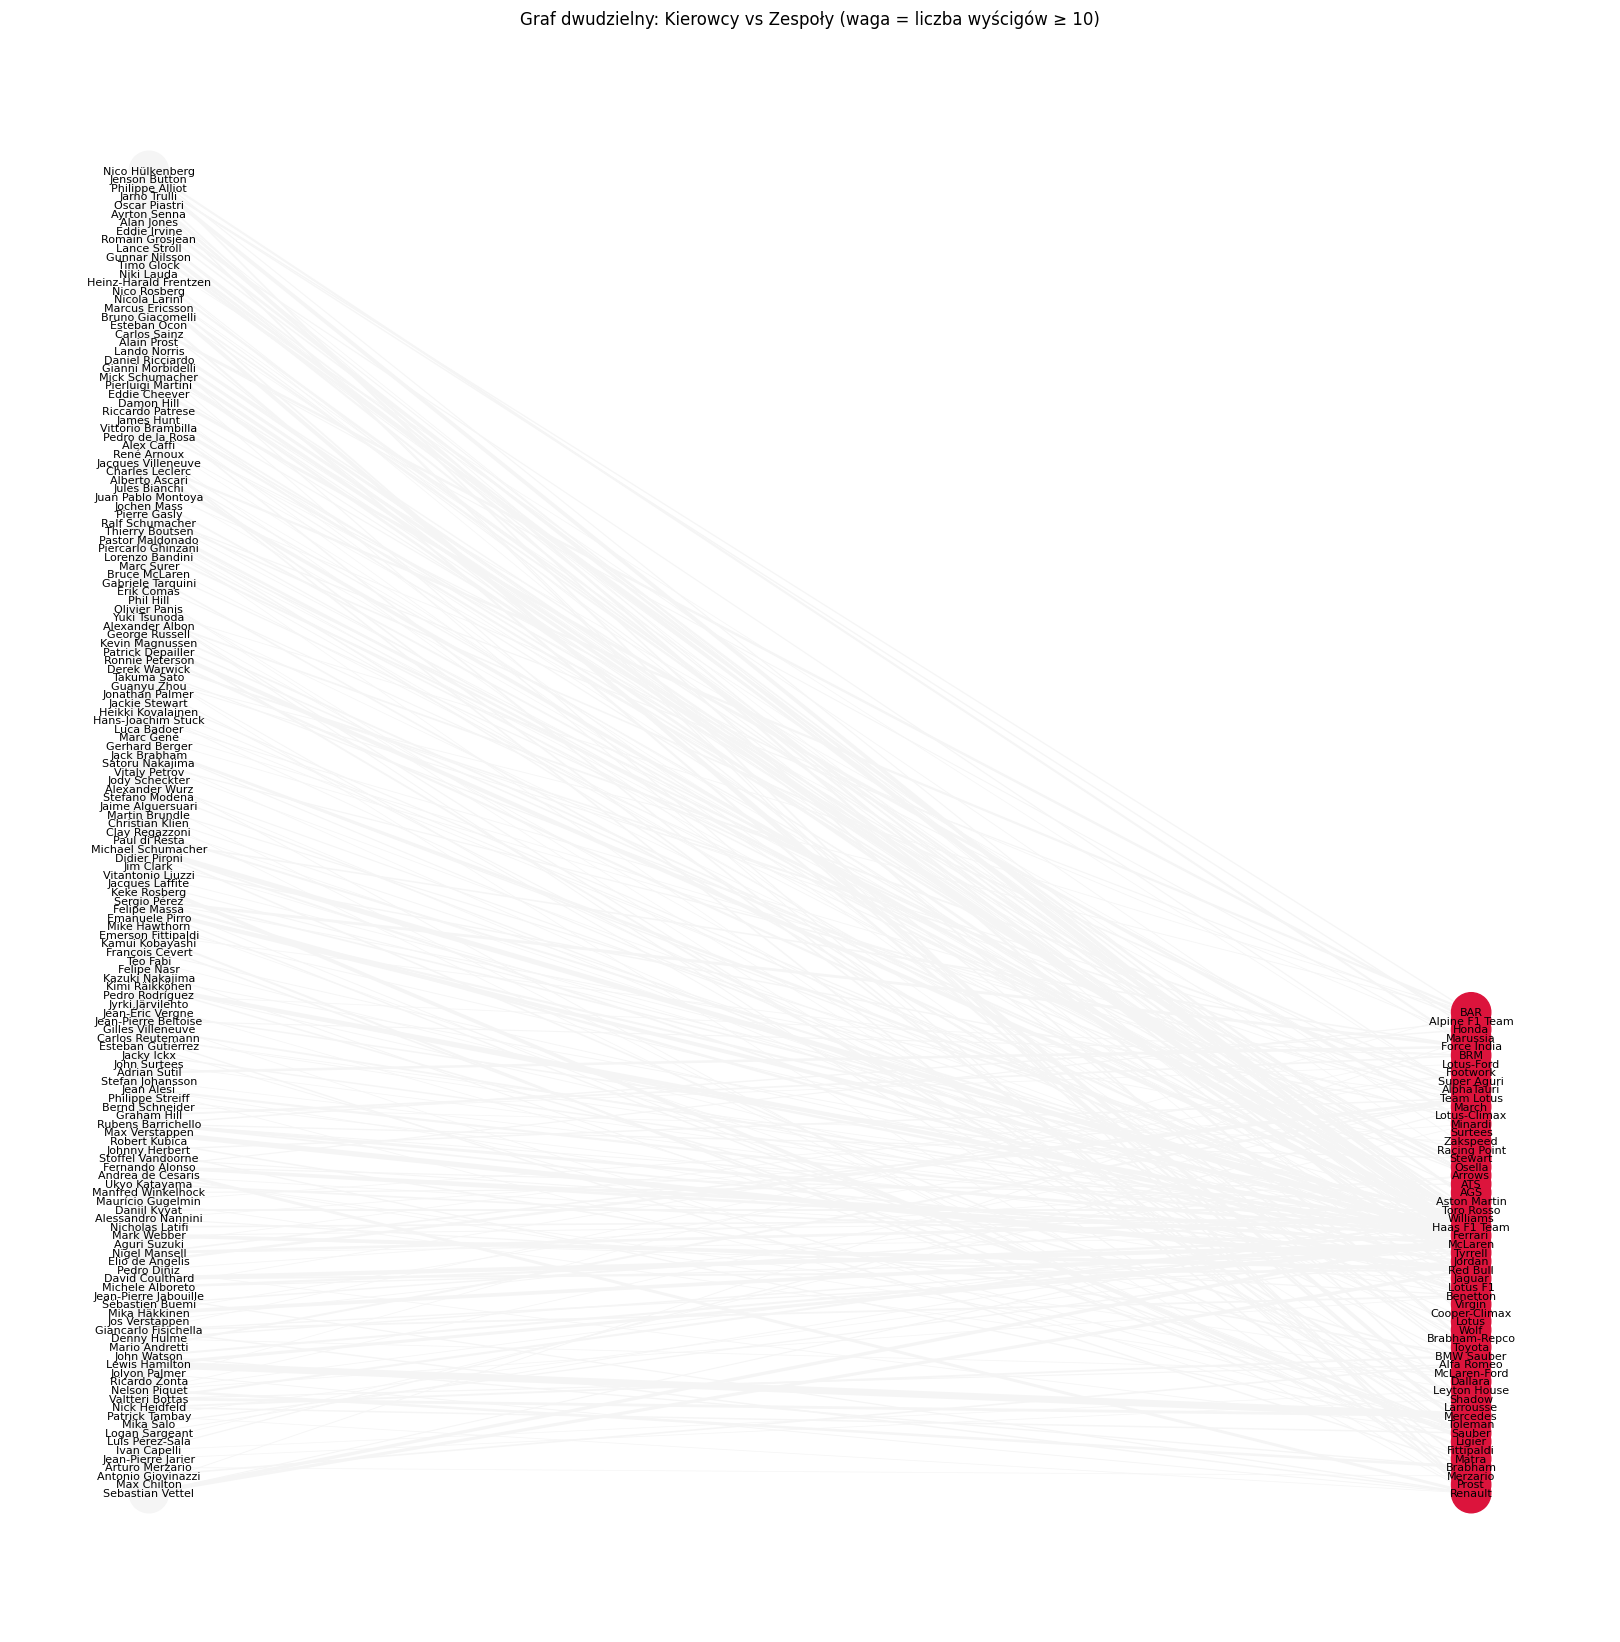

In [84]:

B_filtered = nx.Graph()
for u, v, d in B.edges(data=True):
    if d['weight'] >= min_weight:
        B_filtered.add_edge(u, v, **d)
        B_filtered.nodes[u].update(B.nodes[u])
        B_filtered.nodes[v].update(B.nodes[v])

drivers_nodes = {n for n, d in B_filtered.nodes(data=True) if d['bipartite'] == 0}
teams_nodes = set(B_filtered) - drivers_nodes

pos = dict()
pos.update((node, (1, i)) for i, node in enumerate(drivers_nodes))  # lewa kolumna
pos.update((node, (2, i)) for i, node in enumerate(teams_nodes))    # prawa kolumna

weights = [d['weight'] for _, _, d in B_filtered.edges(data=True)]
min_w = min(weights)
max_w = max(weights)

edge_weights = [
    0.5 + 4.5 * (w - min_w) / (max_w - min_w) for w in weights  #normalizacja
]

node_colors = ['whitesmoke' if n in drivers_nodes else 'crimson' for n in B_filtered.nodes()]

plt.figure(figsize=(16, 16))
nx.draw(
    B_filtered, pos,
    with_labels=True,
    labels=nx.get_node_attributes(B_filtered, 'label'),
    node_color=node_colors,
    edge_color='whitesmoke',
    width=edge_weights,
    node_size=800,
    font_size=8
)
plt.title("Graf dwudzielny: Kierowcy vs Zespoły (waga = liczba wyścigów ≥ 10)")
plt.axis('off')
plt.tight_layout()
plt.savefig('3.png', dpi=300, facecolor='gray')
plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_11316\2909651069.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


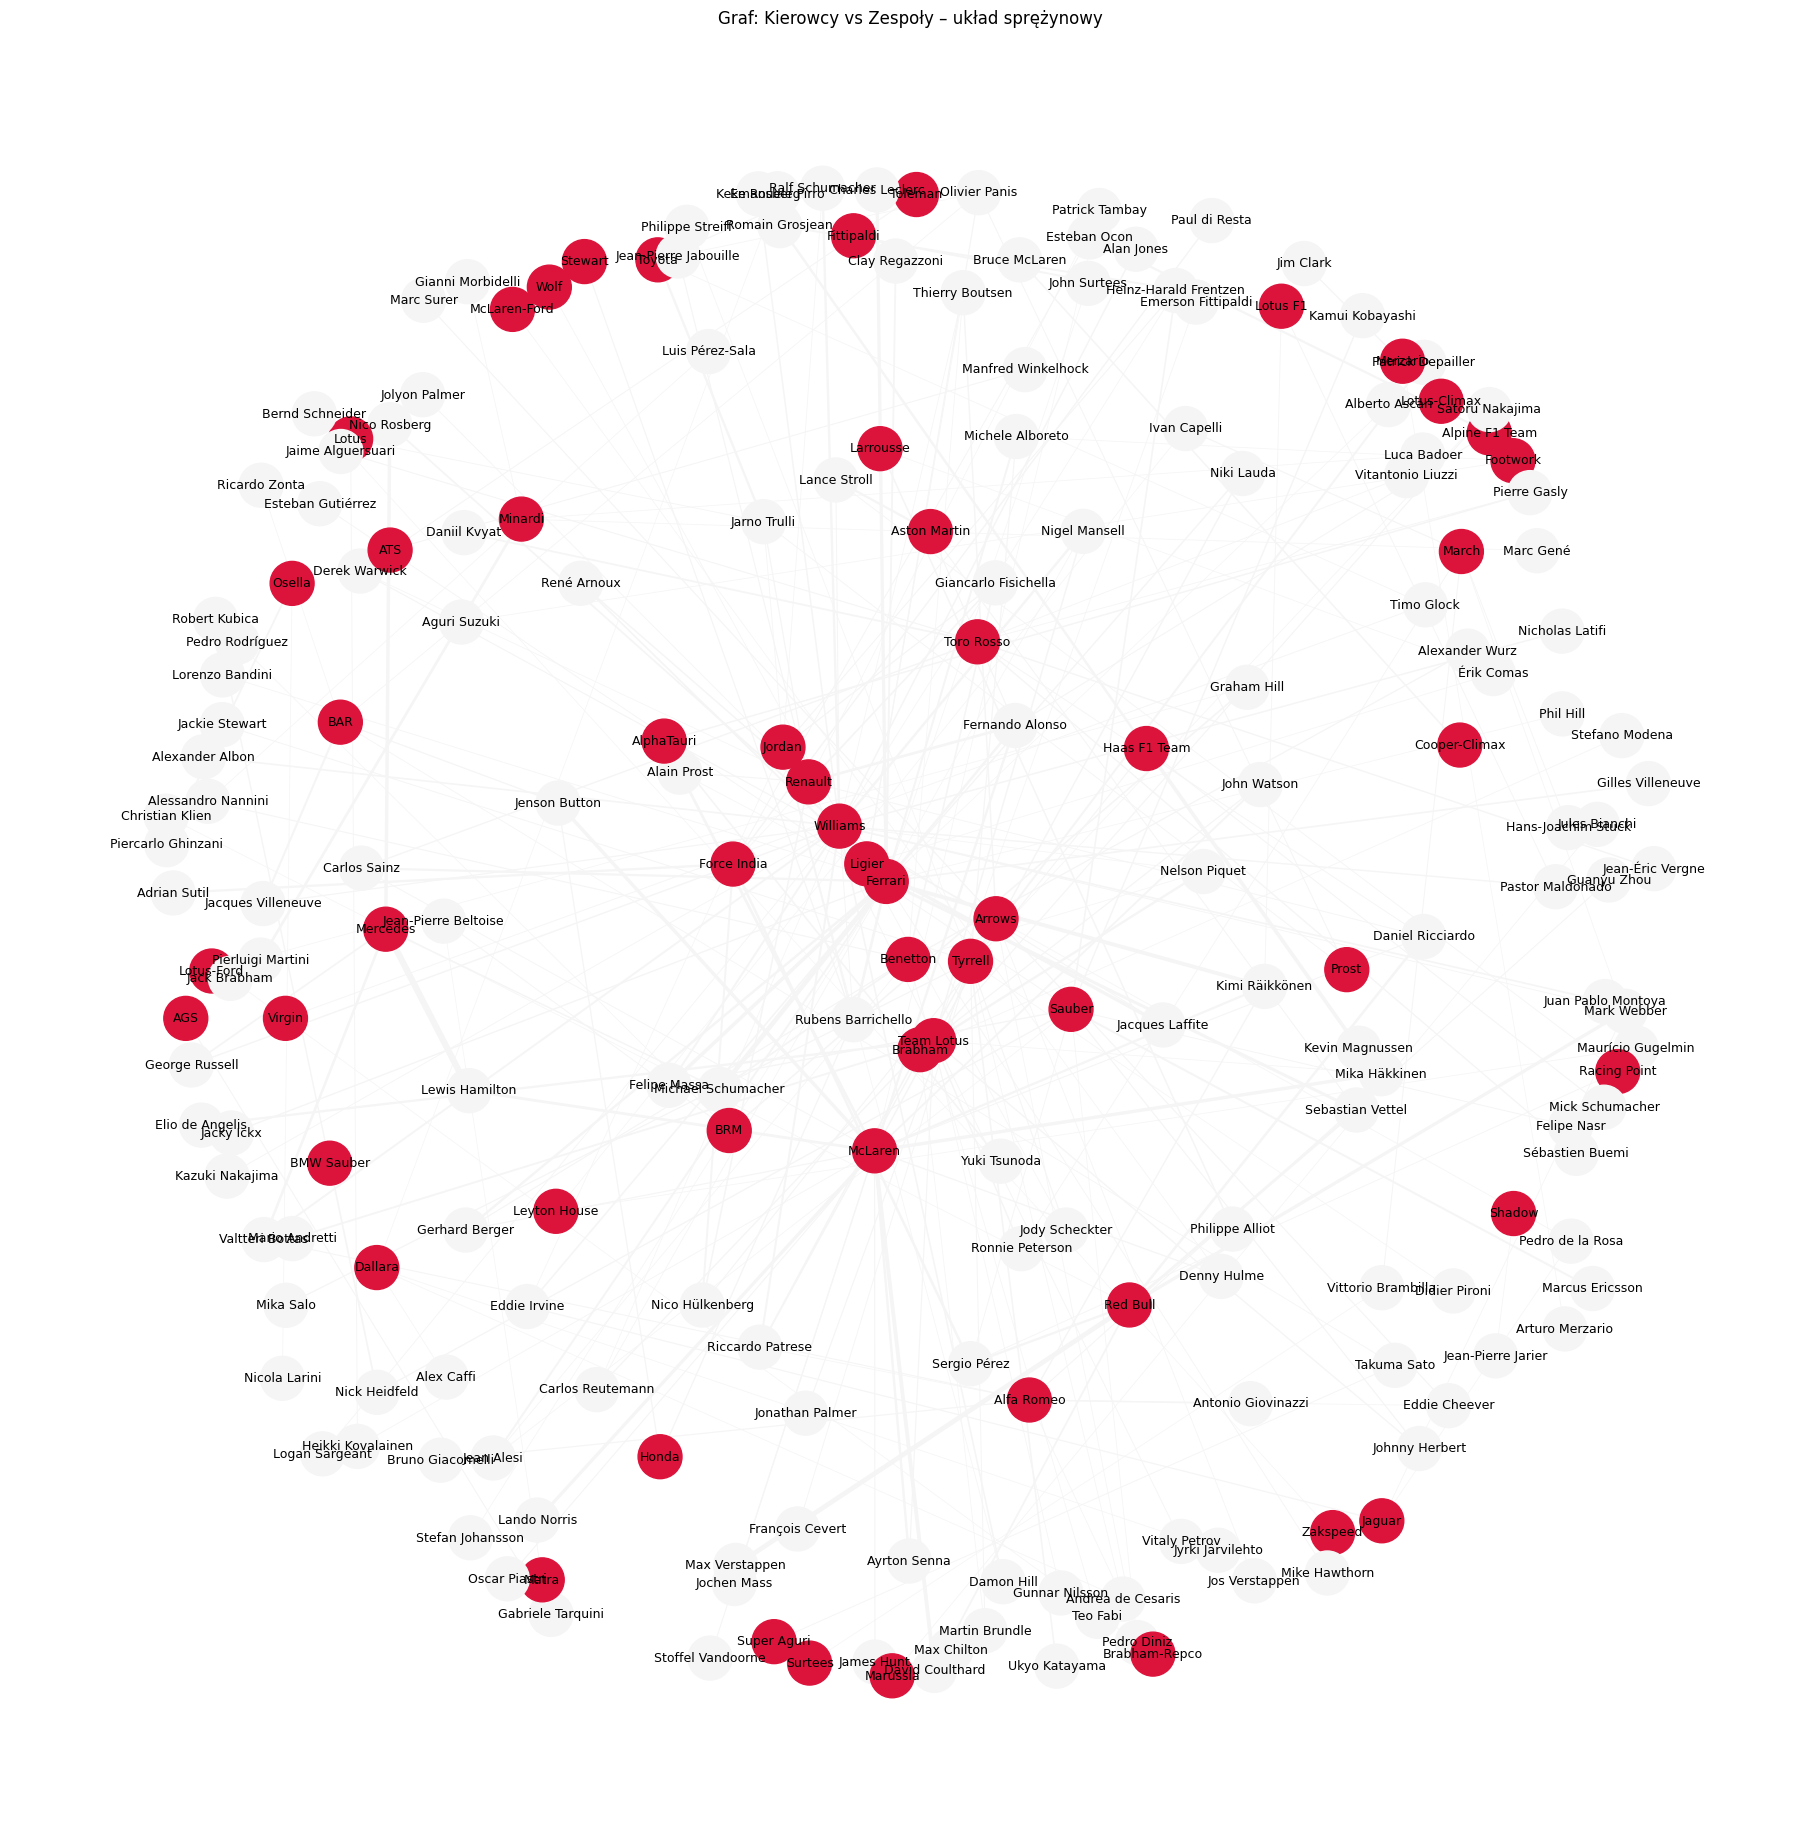

In [85]:
pos = nx.spring_layout(B_filtered, seed=1, k=2.72)  

weights = [d['weight'] for _, _, d in B_filtered.edges(data=True)]
min_w, max_w = min(weights), max(weights)
edge_widths = [0.5 + 4.0 * (w - min_w) / (max_w - min_w) for w in weights]

drivers_nodes = {n for n, d in B_filtered.nodes(data=True) if d['bipartite'] == 0}
node_colors = ['whitesmoke' if n in drivers_nodes else 'crimson' for n in B_filtered.nodes()]

plt.figure(figsize=(18, 18))
nx.draw(
    B_filtered, pos,
    with_labels=True,
    labels=nx.get_node_attributes(B_filtered, 'label'),
    node_color=node_colors,
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=1000,
    font_size=9
)
plt.title("Graf: Kierowcy vs Zespoły – układ sprężynowy")
plt.axis('off')
plt.tight_layout()
plt.savefig('4.png', dpi=300, facecolor='gray')
plt.show()

In [86]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [87]:
results_merge = results.merge(races[['raceId', 'year']], on='raceId', how='left')
results_20to24 = results_merge[results_merge['year'].between(2020, 2024)].copy()

In [88]:
latest_year = 2024
results_20to24['season_weight'] = 0.9 ** (latest_year - results_20to24['year'])

### Wyniki kierowców

In [89]:
driver_scores = results_20to24.groupby(['year', 'driverId']).agg({
    'points': 'sum',
    'positionOrder': ['min', lambda x: (x <= 3).sum(), lambda x: (x == 1).sum()]
})
driver_scores.columns = ['points', 'best_position', 'podiums', 'wins']
driver_scores = driver_scores.reset_index()
driver_scores['score'] = (
    driver_scores['points'] +
    10 * (20 - driver_scores['best_position']) +
    25 * driver_scores['podiums'] +
    100 * driver_scores['wins']
)
driver_champions = (
    driver_scores
    .sort_values(['year', 'points'], ascending=[True, False])
    .drop_duplicates('year')
    .groupby('driverId').size()
    .to_dict()
)
driver_scores['titles'] = driver_scores['driverId'].map(driver_champions).fillna(0)
driver_scores['score'] += 1000 * driver_scores['titles']
driver_scores['season_weight'] = 0.9 ** (latest_year - driver_scores['year'])
driver_scores['weighted_score'] = driver_scores['score'] * driver_scores['season_weight']

total_driver_scores = driver_scores.groupby('driverId')['weighted_score'].sum()
total_driver_scores.index = total_driver_scores.index.astype(str)
total_driver_scores = total_driver_scores.to_dict()

driver_id_to_name = dict(zip(drivers['driverId'], drivers['forename'] + ' ' + drivers['surname']))
total_driver_scores_with_names = {driver_id_to_name.get(int(driver_id), driver_id): score for driver_id, score in total_driver_scores.items()}
sorted_driver_scores = dict(sorted(total_driver_scores_with_names.items(), key=lambda item: item[1], reverse=True))
sorted_driver_scores

{'Max Verstappen': 25169.2684,
 'Lewis Hamilton': 8442.4152,
 'Charles Leclerc': 2941.4168,
 'Sergio Pérez': 2725.9915,
 'Lando Norris': 2508.3512,
 'Carlos Sainz': 2494.2325,
 'George Russell': 1899.6683,
 'Valtteri Bottas': 1520.7228,
 'Oscar Piastri': 1135.8,
 'Fernando Alonso': 1128.5140000000001,
 'Esteban Ocon': 1114.3497,
 'Pierre Gasly': 1077.454,
 'Daniel Ricciardo': 933.5989000000001,
 'Lance Stroll': 817.5755,
 'Alexander Albon': 587.0725,
 'Yuki Tsunoda': 534.588,
 'Sebastian Vettel': 473.75280000000004,
 'Nico Hülkenberg': 455.05400000000003,
 'Kevin Magnussen': 441.47610000000003,
 'Guanyu Zhou': 330.46000000000004,
 'Nicholas Latifi': 249.64200000000002,
 'Liam Lawson': 214.8,
 'Mick Schumacher': 181.44,
 'Logan Sargeant': 180.9,
 'Kimi Räikkönen': 169.5654,
 'Nyck de Vries': 162.72,
 'Antonio Giovinazzi': 157.1724,
 'Oliver Bearman': 137.0,
 'Daniil Kvyat': 125.97120000000001,
 'Franco Colapinto': 125.0,
 'Romain Grosjean': 73.4832,
 'Jack Doohan': 50.0,
 'Robert Kubica

### Wyniki zespołów

In [90]:
team_scores = results_20to24.groupby(['year', 'constructorId']).agg({
    'points': 'sum',
    'positionOrder': ['min', lambda x: (x <= 3).sum(), lambda x: (x == 1).sum()]
})
team_scores.columns = ['points', 'best_position', 'podiums', 'wins']
team_scores = team_scores.reset_index()

team_scores['score'] = (
    team_scores['points'] +
    10 * (20 - team_scores['best_position']) +
    25 * team_scores['podiums'] +
    100 * team_scores['wins']
)
team_champions = (
    team_scores
    .sort_values(['year', 'points'], ascending=[True, False])
    .drop_duplicates('year')
    .groupby('constructorId').size()
    .to_dict()
)
team_scores['titles'] = team_scores['constructorId'].map(team_champions).fillna(0)
team_scores['score'] += 1000 * team_scores['titles']
team_scores['season_weight'] = 0.9 ** (latest_year - team_scores['year'])
team_scores['weighted_score'] = team_scores['score'] * team_scores['season_weight']

total_team_scores = team_scores.groupby('constructorId')['weighted_score'].sum()
total_team_scores.index = total_team_scores.index.astype(str)
total_team_scores = total_team_scores.to_dict()

team_id_to_name = dict(zip(constructors['constructorId'], constructors['name']))
total_team_scores_with_names = {team_id_to_name.get(int(constructor_id), constructor_id): score for constructor_id, score in total_team_scores.items()}
sorted_team_scores = dict(sorted(total_team_scores_with_names.items(), key=lambda item: item[1], reverse=True))
sorted_team_scores

{'Red Bull': 18858.2589,
 'Mercedes': 14606.087300000001,
 'McLaren': 7688.166200000001,
 'Ferrari': 4639.1921,
 'Alpine F1 Team': 1218.155,
 'Aston Martin': 1188.9279999999999,
 'AlphaTauri': 809.1972000000001,
 'Williams': 608.241,
 'Haas F1 Team': 596.7893,
 'Alfa Romeo': 461.20680000000004,
 'Racing Point': 393.66,
 'Renault': 286.0596,
 'RB F1 Team': 170.0,
 'Sauber': 124.0}

C:\Users\micha\AppData\Local\Temp\ipykernel_11316\1327547407.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


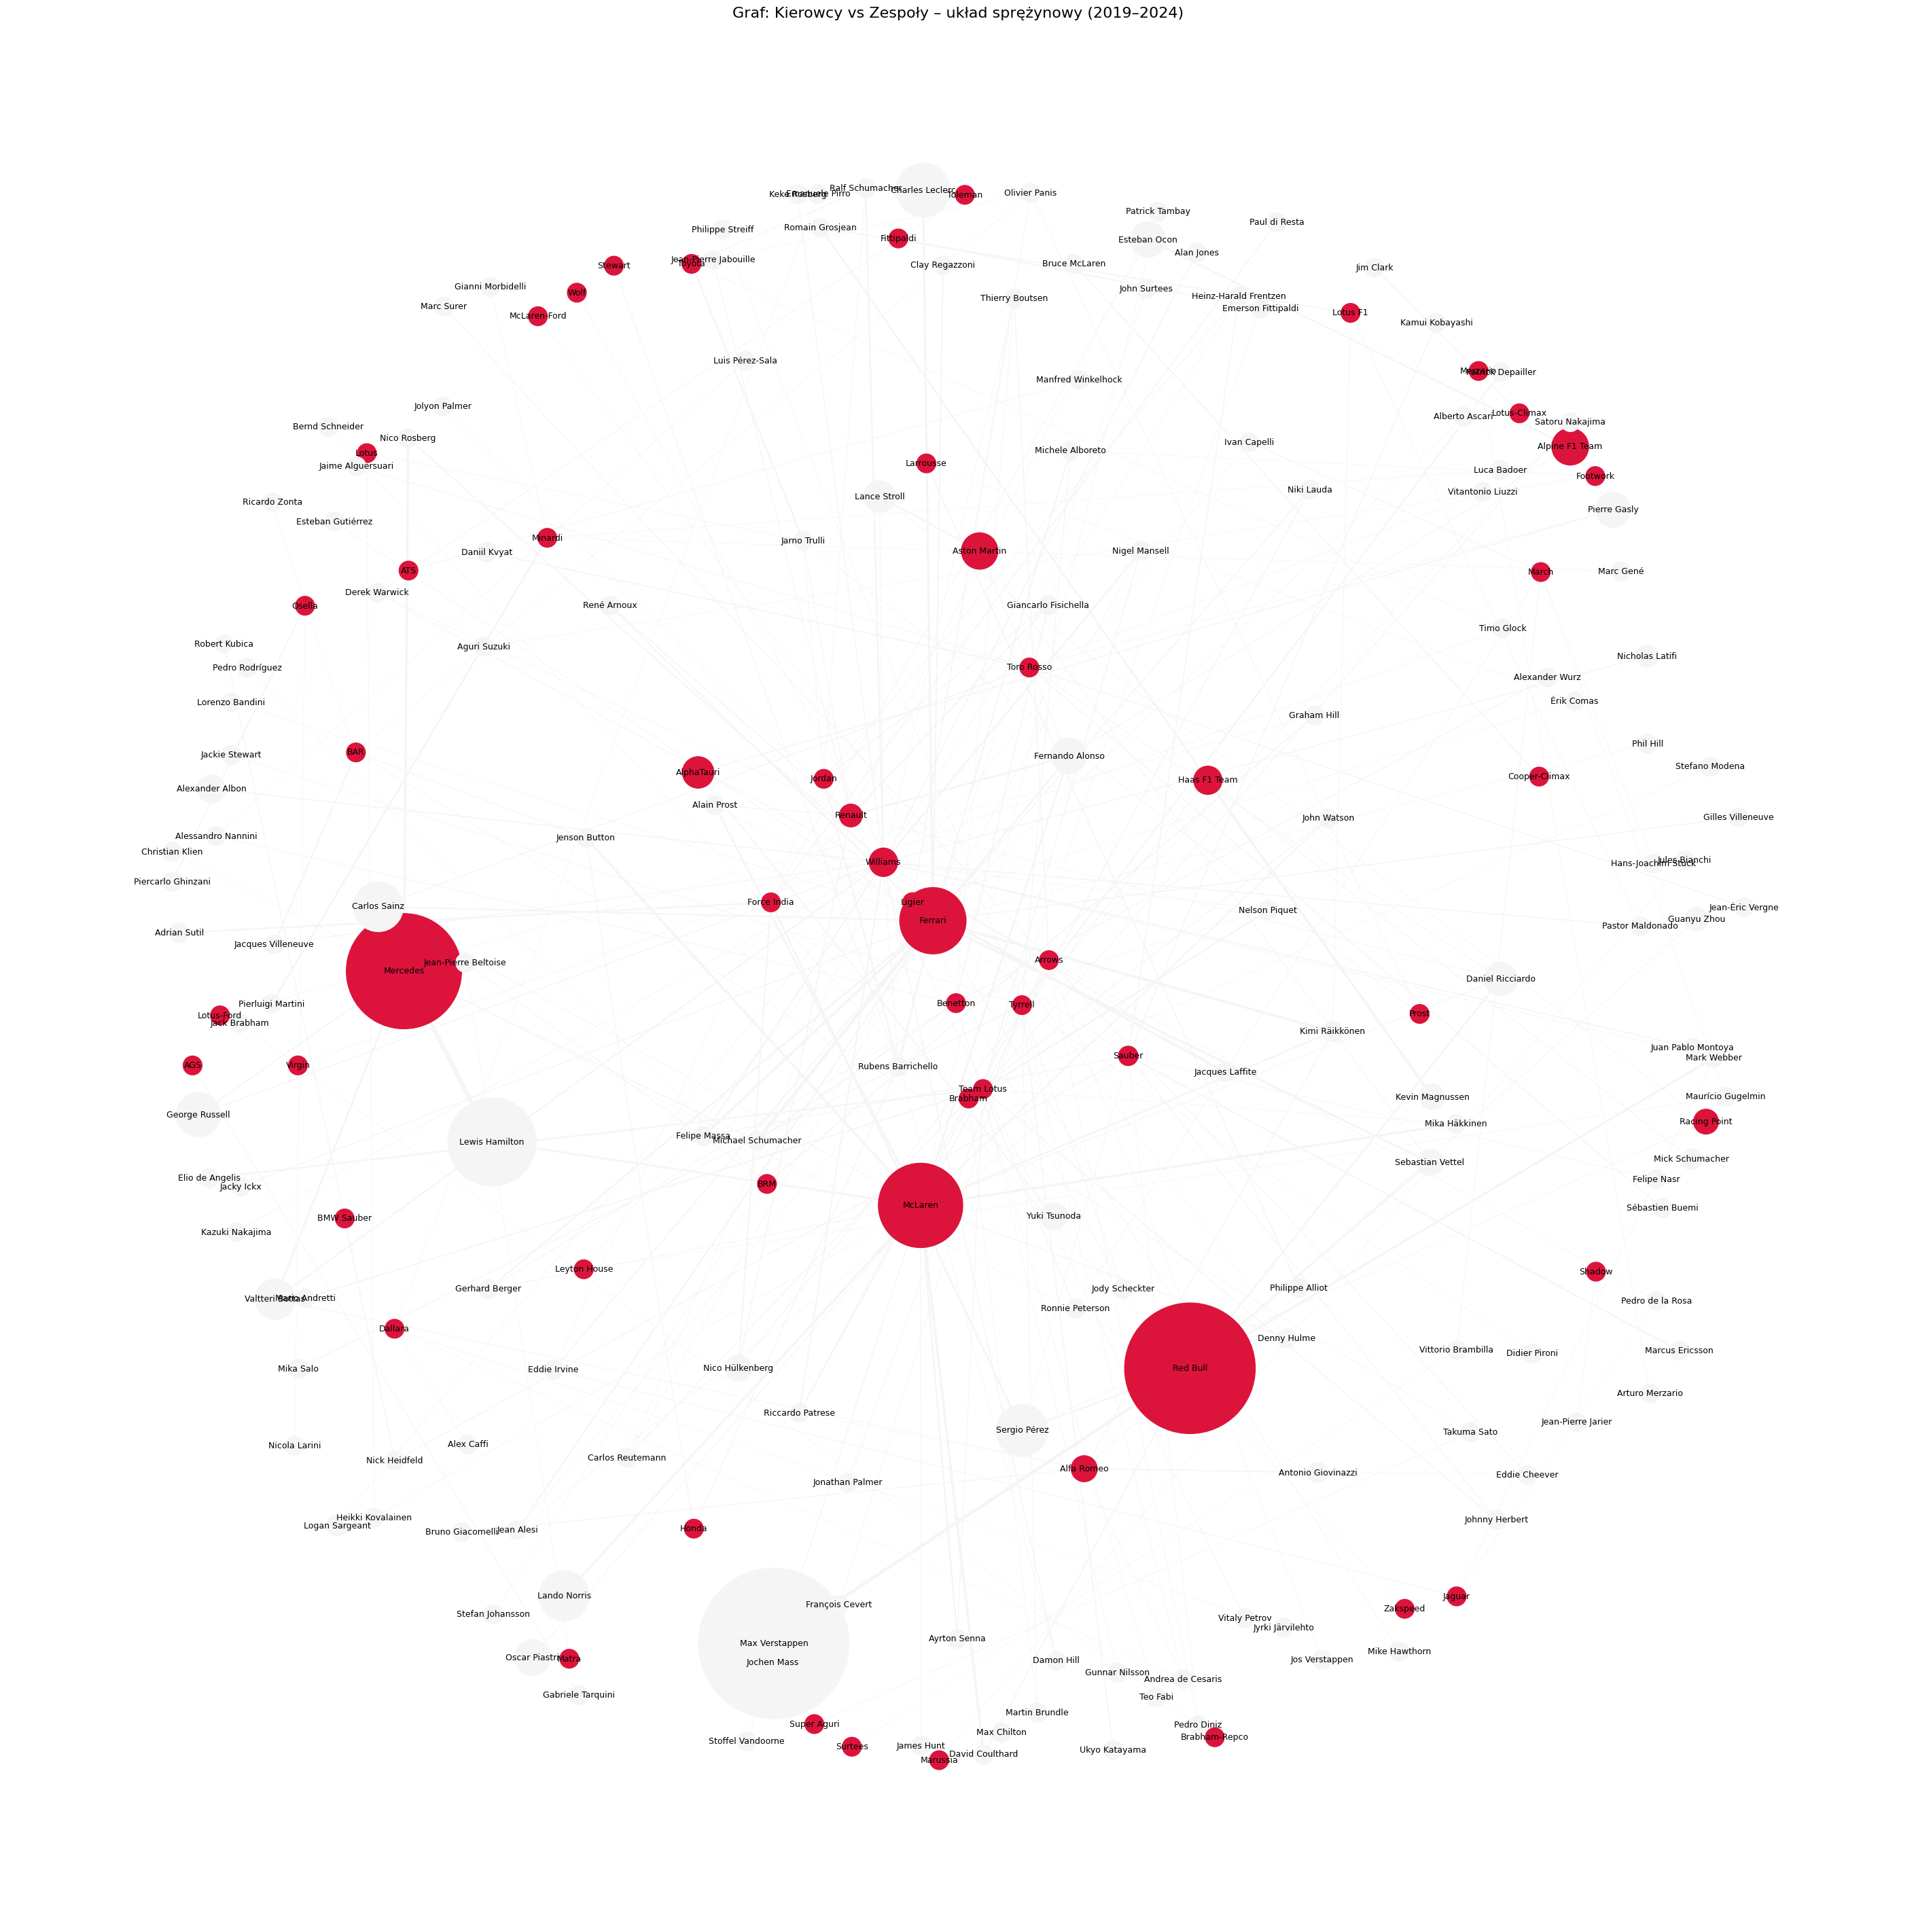

In [91]:
node_sizes = []
best_team = None
best_team_score = 0
for node in B_filtered.nodes(data=True):
    n_id = node[0] 
    n_type = node[1]['bipartite']
    n_raw_id = n_id.split('_')[1]  
    if n_type == 0:
        size = total_driver_scores.get(n_raw_id, 100)
    else: 
        size = total_team_scores.get(n_raw_id, 100)
        if size > best_team_score:
            best_team_score = size
            best_team = node
    node_sizes.append(300 + size)

plt.figure(figsize=(28, 28))  
nx.draw(
    B_filtered,
    pos,
    with_labels=True,
    labels=nx.get_node_attributes(B_filtered, 'label'),
    node_color=node_colors,
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=node_sizes,  
    font_size=9
)
plt.title("Graf: Kierowcy vs Zespoły – układ sprężynowy (2019–2024)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('5.png', dpi=300, facecolor='gray')
plt.show()


('c_9', {'label': 'Red Bull', 'bipartite': 1})


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\335796990.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


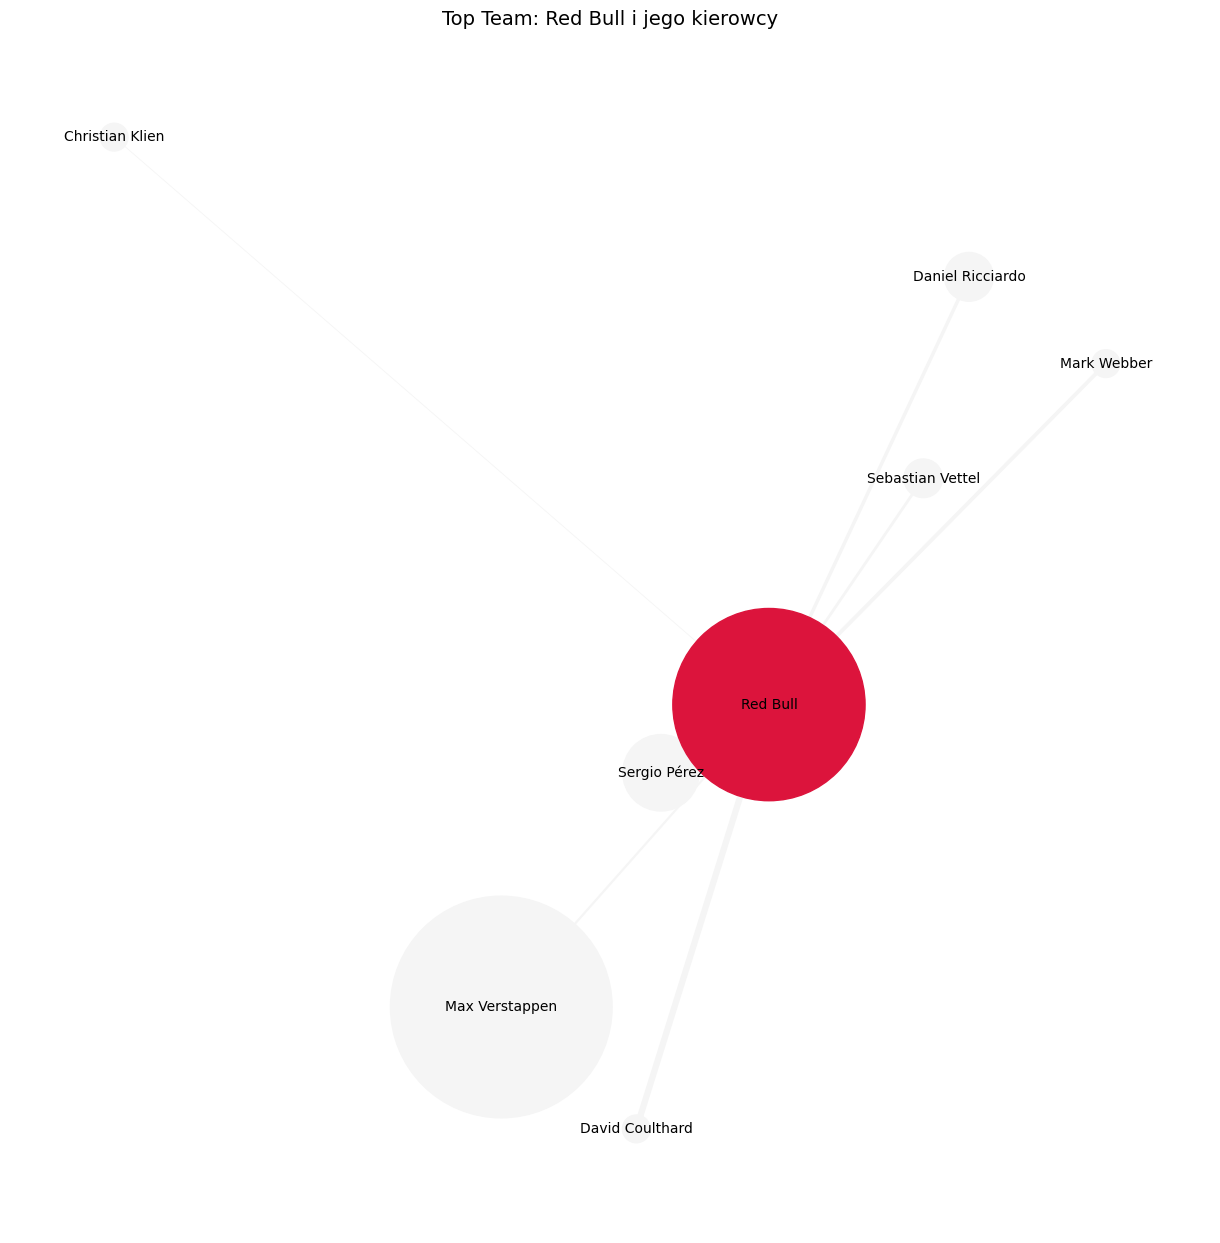

In [92]:
print(best_team)
top_team_node = best_team[0]
connected_drivers = list(B_filtered.neighbors(top_team_node))

subgraph_nodes = [top_team_node] + connected_drivers
subgraph = B_filtered.subgraph(subgraph_nodes)

plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=[node_sizes[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    font_size=10
)
plt.title(f"Top Team: {B_filtered.nodes[top_team_node]['label']} i jego kierowcy", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('6.png', dpi=300, facecolor='gray')
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\4106369342.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


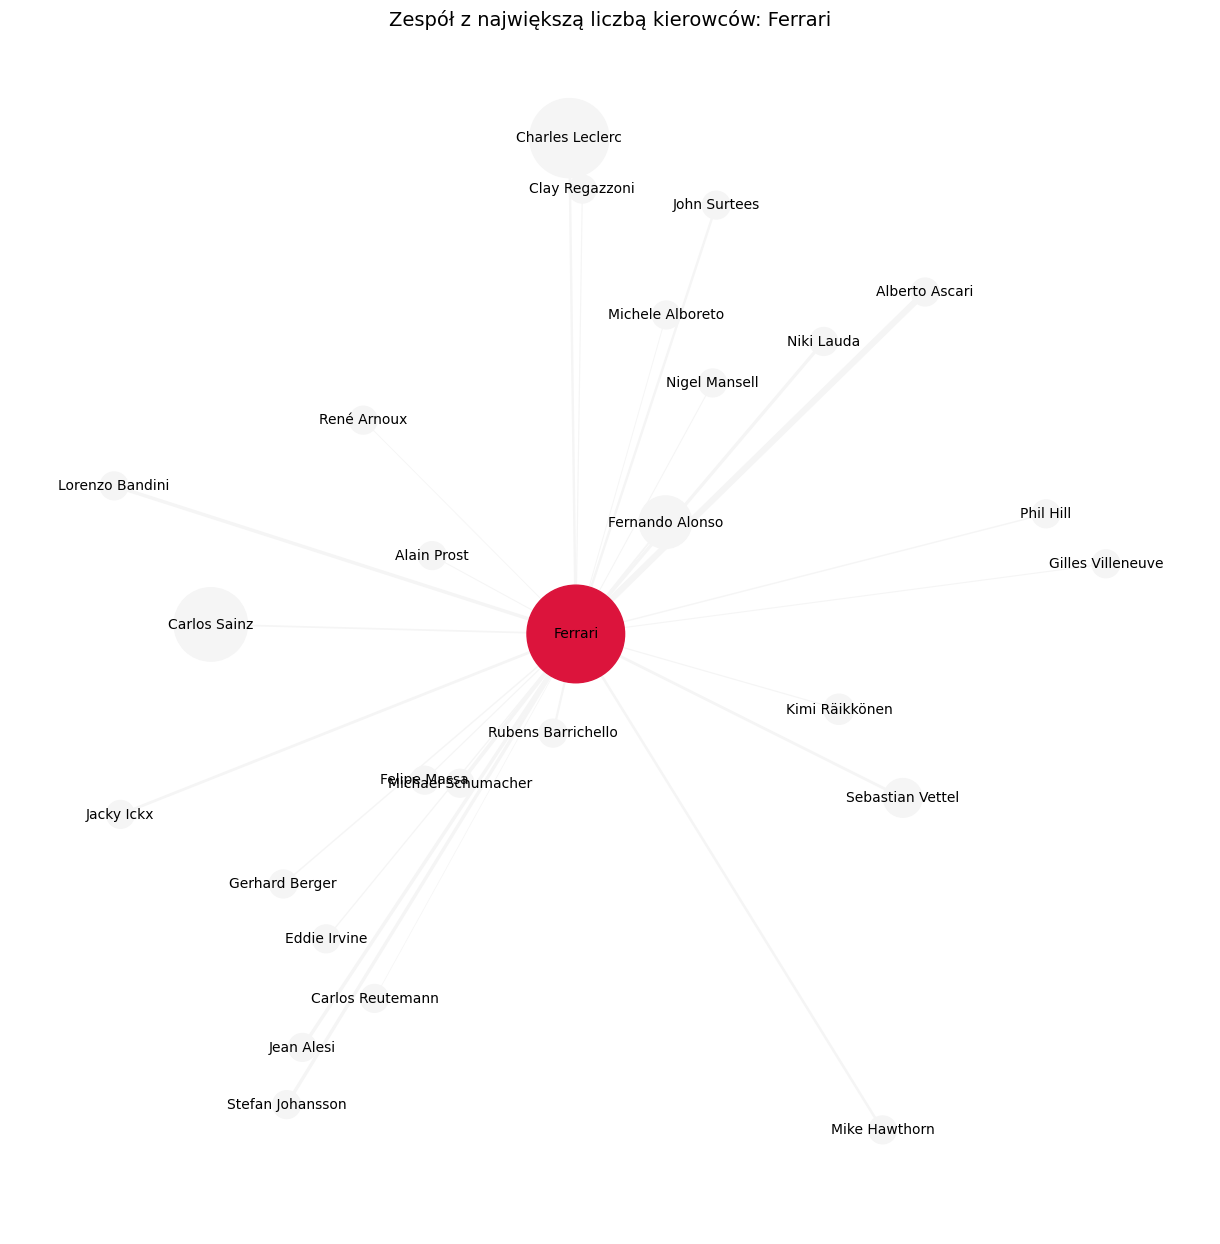

In [93]:
team_nodes = [n for n, d in B_filtered.nodes(data=True) if d['bipartite'] == 1]
team_driver_counts = {team: len(list(B_filtered.neighbors(team))) for team in team_nodes}
team_most_drivers = max(team_driver_counts.items(), key=lambda x: x[1])[0]
drivers_for_team = list(B_filtered.neighbors(team_most_drivers))

subgraph_nodes = [team_most_drivers] + drivers_for_team
subgraph = B_filtered.subgraph(subgraph_nodes)

plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=[node_sizes[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    font_size=10
)
plt.title(f"Zespół z największą liczbą kierowców: {B_filtered.nodes[team_most_drivers]['label']}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('7.png', dpi=300, facecolor='gray')
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\2276214938.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


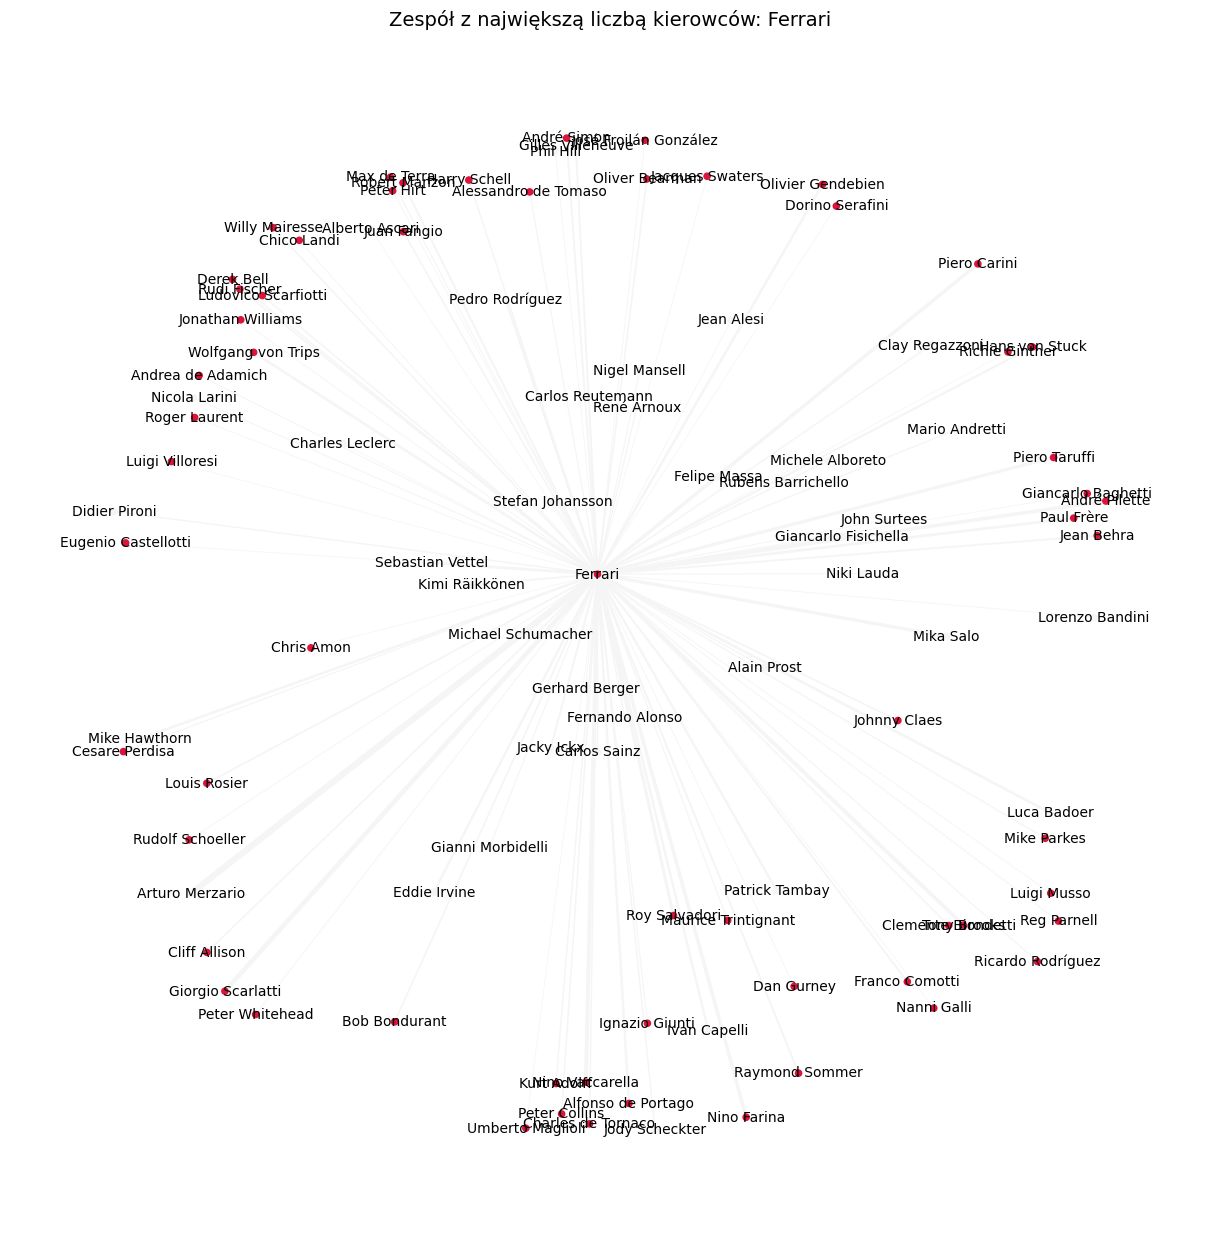

In [94]:
team_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 1]
team_driver_counts = {team: len(list(B.neighbors(team))) for team in team_nodes}
team_most_drivers = max(team_driver_counts.items(), key=lambda x: x[1])[0]
drivers_for_team = list(B.neighbors(team_most_drivers))

subgraph_nodes = [team_most_drivers] + drivers_for_team
subgraph = B.subgraph(subgraph_nodes)
node_colors_full = ['whitesmoke' if n in drivers_nodes else 'crimson' for n in B.nodes()]
plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos1[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors_full[list(B.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=20,
    font_size=10
)
plt.title(f"Zespół z największą liczbą kierowców: {B.nodes[team_most_drivers]['label']}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('8.png', dpi=300, facecolor='gray')
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\2318944074.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


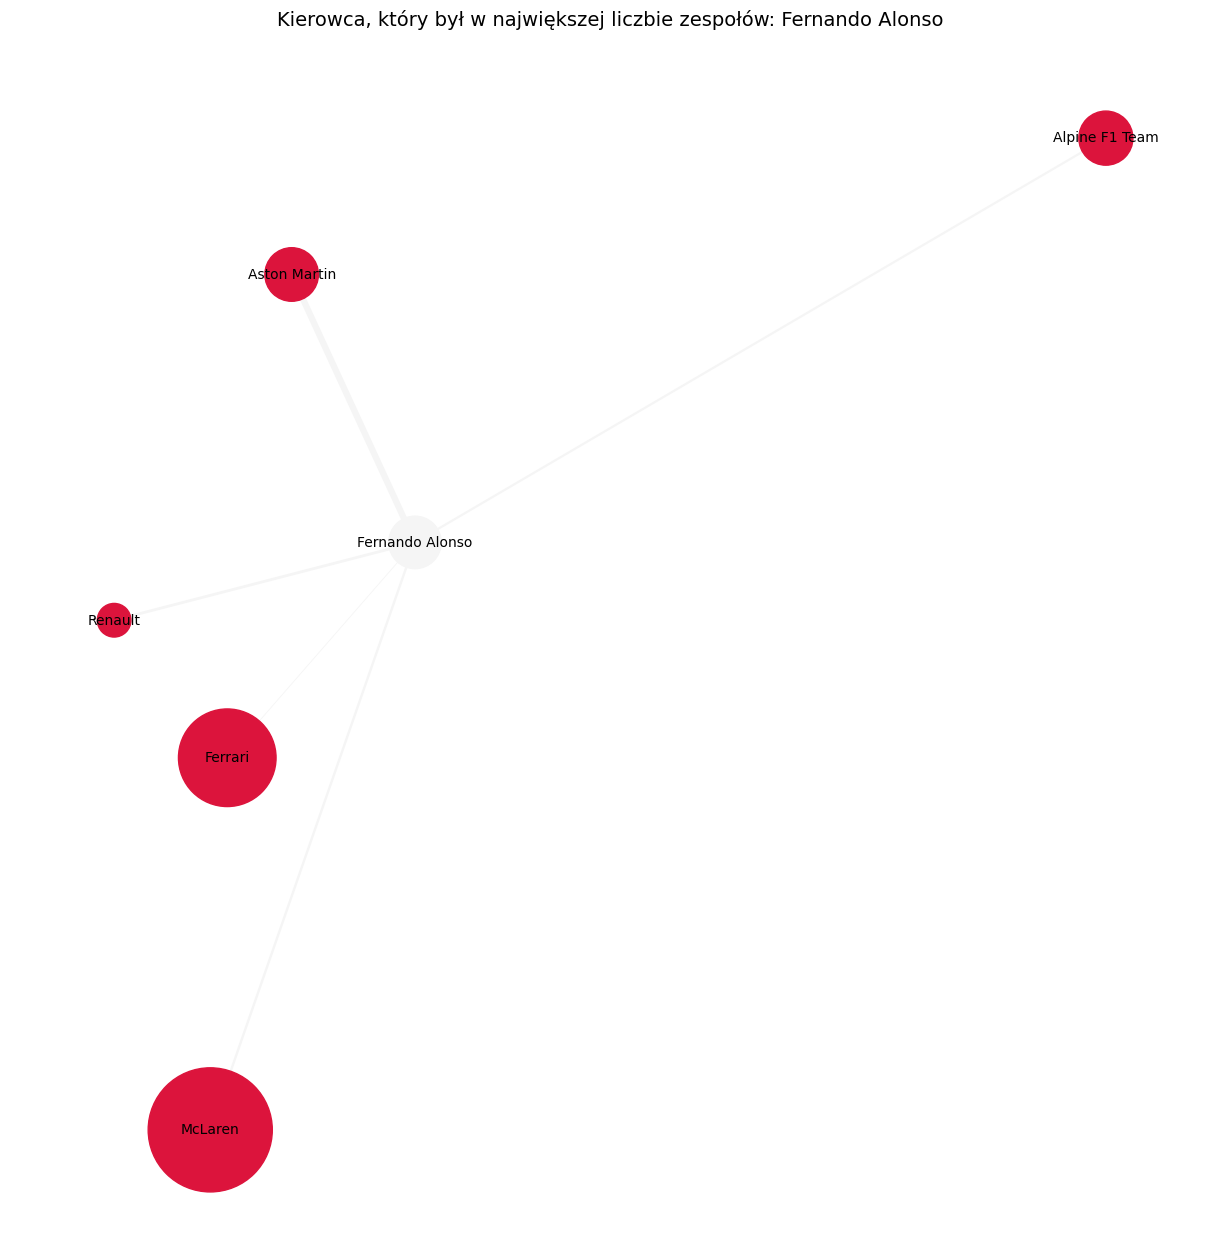

In [95]:
# 1. Filtruj węzły zespołów
team_nodes = [n for n, d in B_filtered.nodes(data=True) if d['bipartite'] == 0]

# 2. Zlicz kierowców dla każdego zespołu
team_driver_counts = {team: len(list(B_filtered.neighbors(team))) for team in team_nodes}

# 3. Znajdź zespół z największą liczbą kierowców
team_most_drivers = max(team_driver_counts.items(), key=lambda x: x[1])[0]

# 4. Znajdź jego kierowców
drivers_for_team = list(B_filtered.neighbors(team_most_drivers))

# 5. Podgraf
subgraph_nodes = [team_most_drivers] + drivers_for_team
subgraph = B_filtered.subgraph(subgraph_nodes)

# 6. Rysowanie
plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=[node_sizes[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    font_size=10
)
plt.title(f"Kierowca, który był w największej liczbie zespołów: {B_filtered.nodes[team_most_drivers]['label']}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('9.png', dpi=300, facecolor='gray')
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\237645962.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


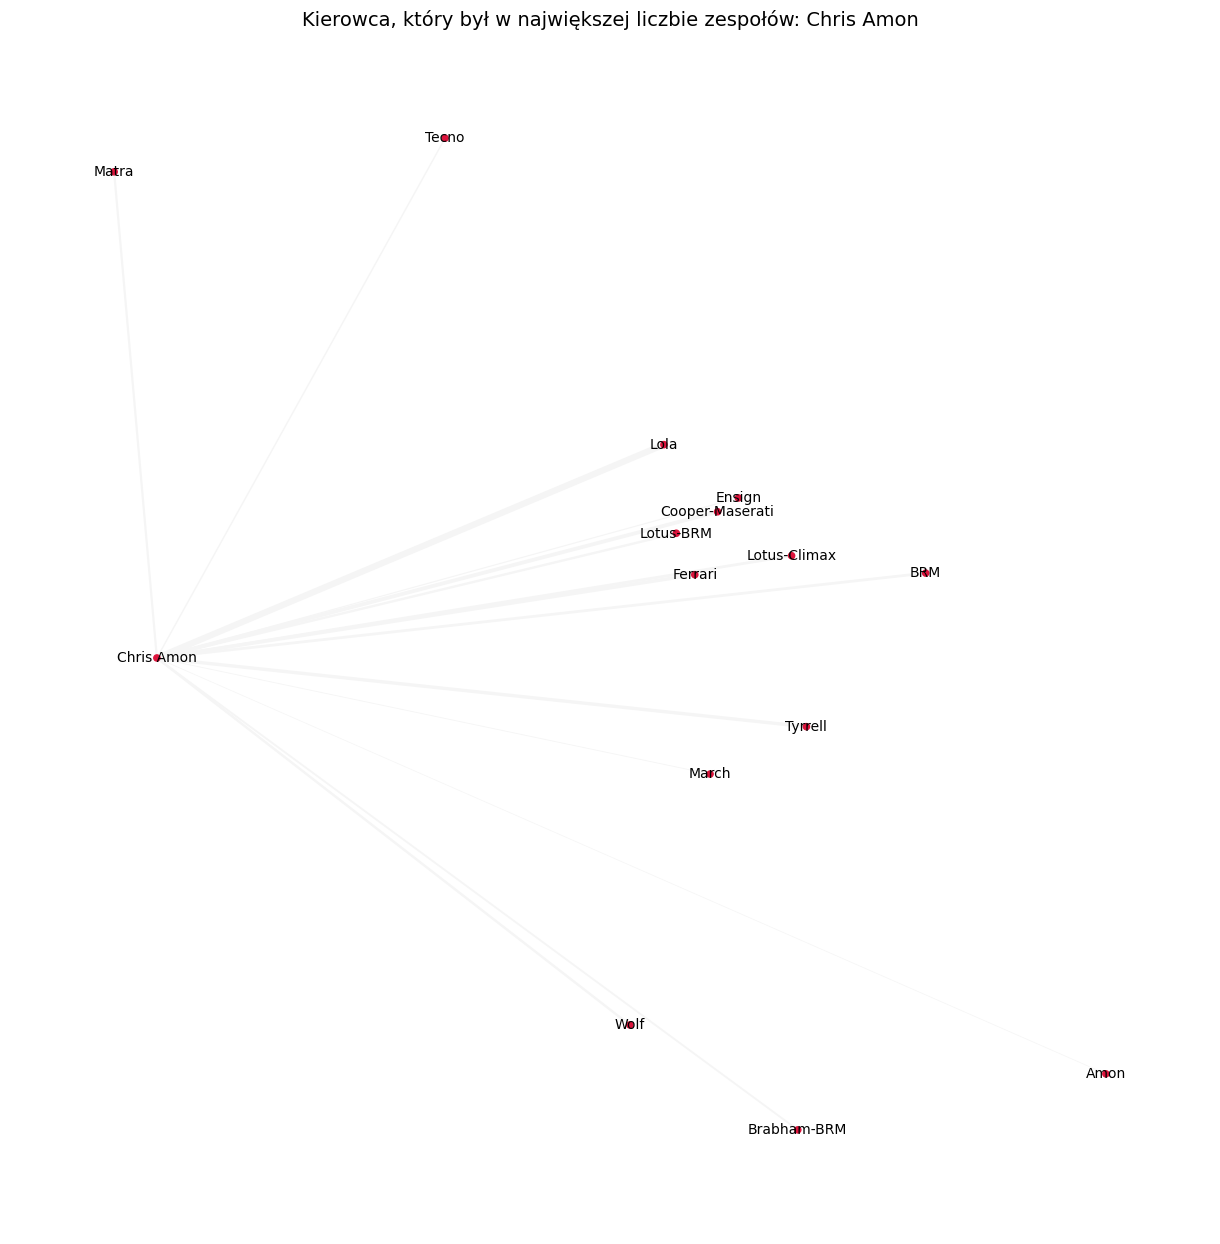

In [96]:
# 1. Filtruj węzły zespołów
team_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]

# 2. Zlicz kierowców dla każdego zespołu
team_driver_counts = {team: len(list(B.neighbors(team))) for team in team_nodes}

# 3. Znajdź zespół z największą liczbą kierowców
team_most_drivers = max(team_driver_counts.items(), key=lambda x: x[1])[0]

# 4. Znajdź jego kierowców
drivers_for_team = list(B.neighbors(team_most_drivers))

# 5. Podgraf
subgraph_nodes = [team_most_drivers] + drivers_for_team
subgraph = B.subgraph(subgraph_nodes)

# 6. Rysowanie
plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos1[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors_full[list(B.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=20,
    font_size=10
)
plt.title(f"Kierowca, który był w największej liczbie zespołów: {B.nodes[team_most_drivers]['label']}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('10.png', dpi=300, facecolor='gray')
plt.show()


('c_9', {'label': 'Red Bull', 'bipartite': 1})


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\3388740645.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


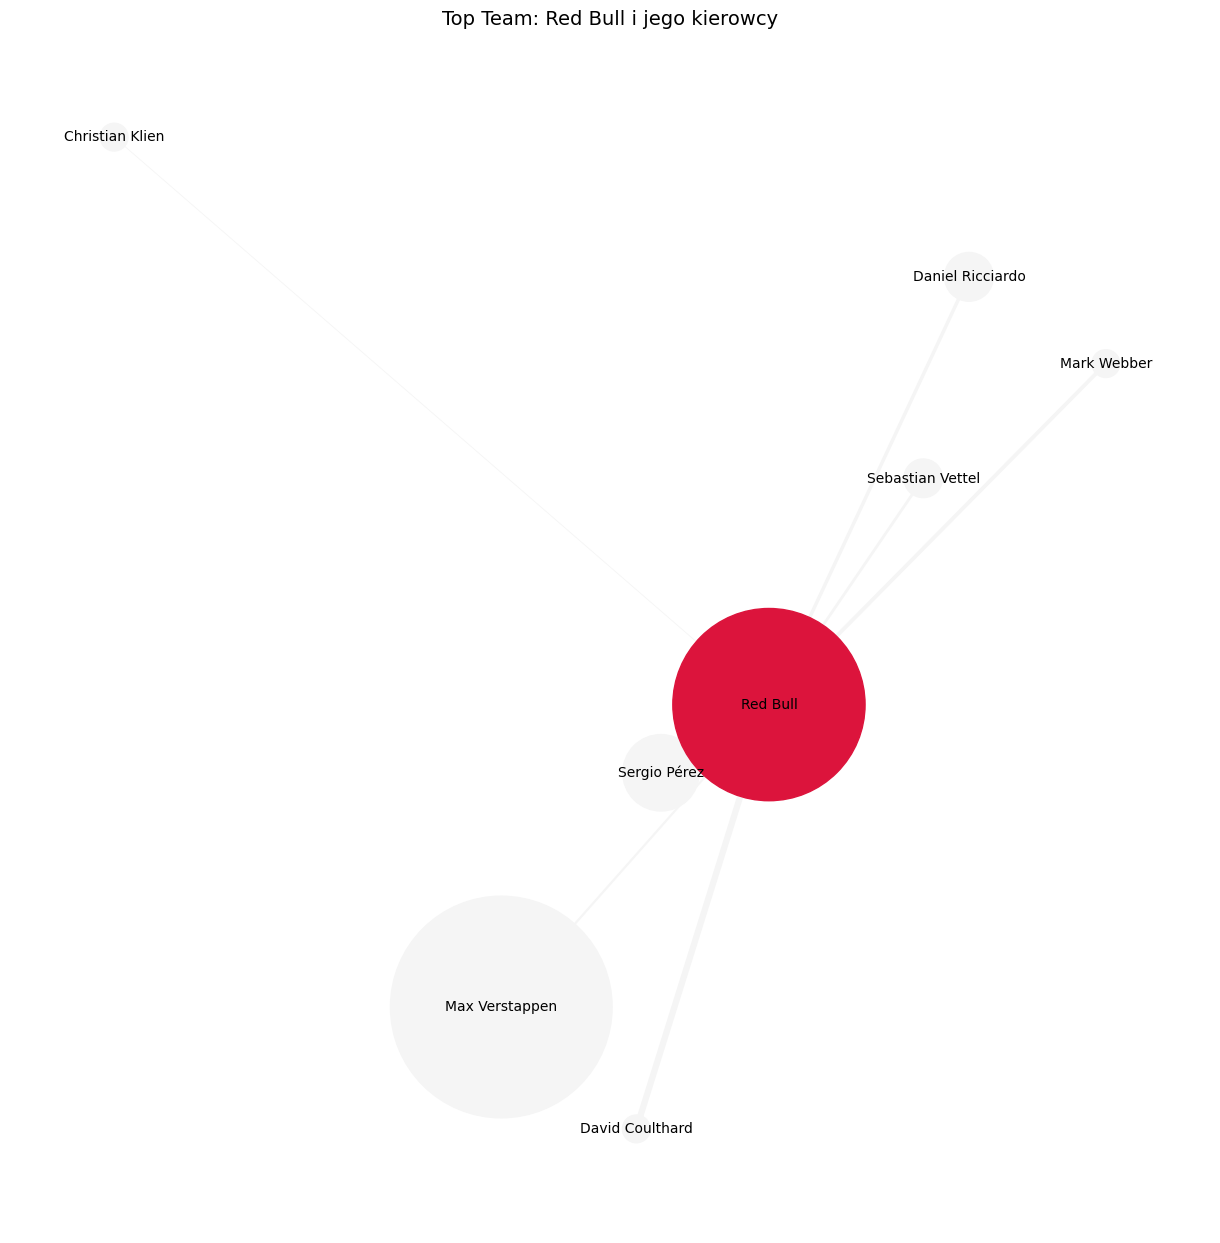

In [97]:
print(best_team)
top_team_node = best_team[0]

# 3. Kierowcy współpracujący z tym zespołem
connected_drivers = list(B_filtered.neighbors(top_team_node))

# 4. Tworzenie listy węzłów do podgrafu
subgraph_nodes = [top_team_node] + connected_drivers

# 5. Tworzenie podgrafu
subgraph = B_filtered.subgraph(subgraph_nodes)

# 6. Rysowanie podgrafu
plt.figure(figsize=(12, 12))
nx.draw(
    subgraph,
    pos={n: pos[n] for n in subgraph.nodes()},
    with_labels=True,
    labels=nx.get_node_attributes(subgraph, 'label'),
    node_color=[node_colors[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=[node_sizes[list(B_filtered.nodes()).index(n)] for n in subgraph.nodes()],
    font_size=10
)
plt.title(f"Top Team: {B_filtered.nodes[top_team_node]['label']} i jego kierowcy", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('11.png', dpi=300, facecolor='gray')
plt.show()


C:\Users\micha\AppData\Local\Temp\ipykernel_11316\3058561990.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


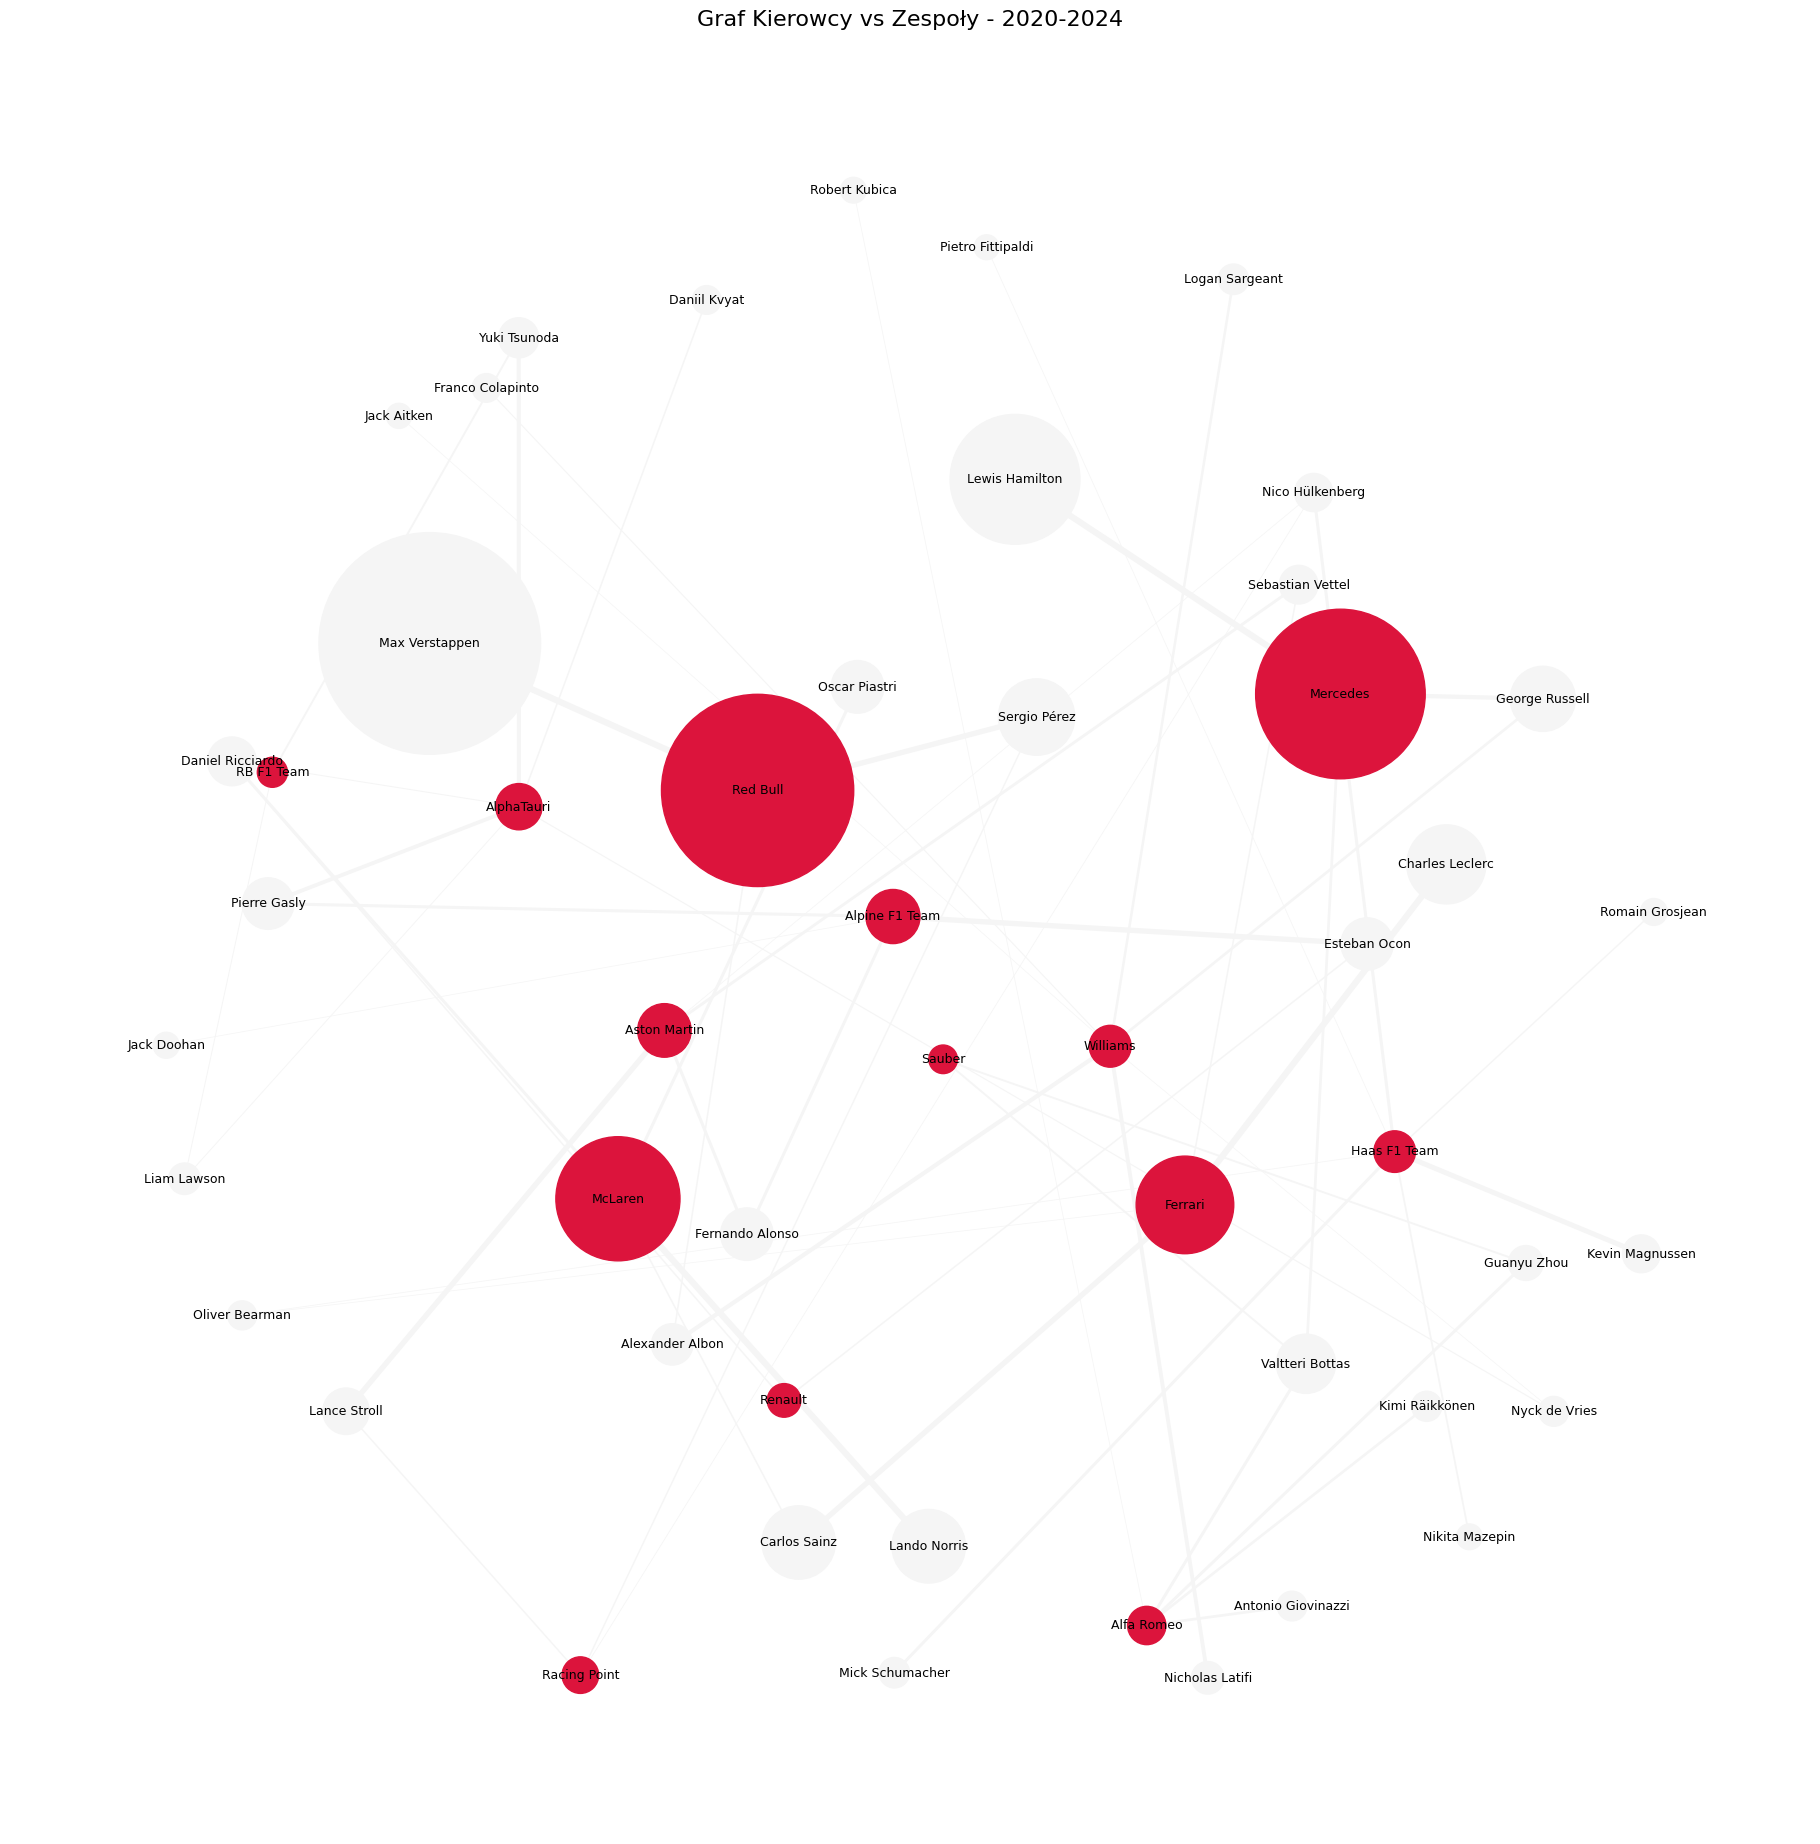

In [98]:
results_filtered = results_20to24
drivers_filtered = results_filtered['driverId'].unique()
B_2024 = nx.Graph()

for driver_id in drivers_filtered:
    driver_node = f'd_{driver_id}'
    driver_name = B.nodes[driver_node]['label']
    B_2024.add_node(driver_node, label=driver_name, bipartite=0)
    B_2024.nodes[driver_node].update(B.nodes[driver_node])

for driver_id in drivers_filtered:
    driver_node = f'd_{driver_id}'
    for neighbor in B.neighbors(driver_node):
        team_id = neighbor.split('_')[1]

        relevant_results = results_filtered[(results_filtered['driverId'] == driver_id) & 
                                            (results_filtered['constructorId'] == int(team_id))]

        if relevant_results.shape[0] > 0:  
            if not B_2024.has_node(neighbor):
                B_2024.add_node(neighbor)
            B_2024.nodes[neighbor].update(B.nodes[neighbor])

            edge_weight = relevant_results.shape[0]
            B_2024.add_edge(driver_node, neighbor, weight=edge_weight)

node_sizes_2024 = []
for node in B_2024.nodes(data=True):
    n_id = node[0]
    n_type = node[1]['bipartite']
    n_raw_id = n_id.split('_')[1]
    
    if n_type == 0:
        size = total_driver_scores.get(n_raw_id, 100)
    else:
        size = total_team_scores.get(n_raw_id, 100)
    
    node_sizes_2024.append(300 + size)

pos2 = nx.spring_layout(B_2024, seed=10, k=3.14)

weights = [d['weight'] for _, _, d in B_2024.edges(data=True)]
min_w, max_w = min(weights), max(weights)
edge_widths = [0.5 + 4.0 * (w - min_w) / (max_w - min_w) for w in weights]

drivers_nodes = {n for n, d in B_2024.nodes(data=True) if d['bipartite'] == 0}
node_colors = ['whitesmoke' if n in drivers_nodes else 'crimson' for n in B_2024.nodes()]

plt.figure(figsize=(18, 18))
nx.draw(
    B_2024, pos2,
    with_labels=True,
    labels=nx.get_node_attributes(B_2024, 'label'),
    node_color=node_colors,
    edge_color='whitesmoke',
    width=edge_widths,
    node_size=node_sizes_2024,
    font_size=9
)
plt.title("Graf Kierowcy vs Zespoły - 2020-2024", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('12.png', dpi=300, facecolor='gray')
plt.show()

In [99]:
from itertools import islice


def metrics(B, node, total_races):
    races = total_races.get(node.split('_')[1], 0)
    degree_centrality = nx.degree_centrality(B)[node] * races
    betweenness_centrality = nx.betweenness_centrality(B, normalized=True).get(node, 0) * races
    closeness_centrality = nx.closeness_centrality(B).get(node, 0) * races
    return degree_centrality, betweenness_centrality, closeness_centrality

def driver_power(B, total_driver_scores, total_team_scores, min_weight=10):
    drivers_power = {}
    
    for node, data in B.nodes(data=True):
        if data['bipartite'] == 0:  # Kierowcy
            driver_id = node.split('_')[1]
            driver_name = data['label']
            driver_score = total_driver_scores.get(driver_id, 100)
            driver_races = sum([d['weight'] for _, _, d in B.edges(node, data=True)])
            
            teams_score = 0
            teams_degree = 0
            teams_betweenness = 0
            teams_closeness = 0
            
            driver_degree, driver_betweenness, driver_closeness = metrics(B, node, total_driver_scores)            
            for neighbor in B.neighbors(node):
                if 'c_' in neighbor:
                    team_id = neighbor.split('_')[1]
                    team_score = total_team_scores.get(team_id, 100)
                    
                    edge_weight = B.get_edge_data(node, neighbor)['weight']                   

                    team_degree, team_betweenness, team_closeness = metrics(B, neighbor, total_team_scores)
                    
                    teams_score += (edge_weight / driver_races) * team_score
                    teams_degree += (edge_weight / driver_races) * team_degree
                    teams_betweenness += (edge_weight / driver_races) * team_betweenness
                    teams_closeness += (edge_weight / driver_races) * team_closeness

            drivers_power[driver_name] = round((driver_score / teams_score ** 0.5) + (driver_degree / teams_degree ** 0.5) + (driver_betweenness / teams_betweenness ** 0.5) + (driver_closeness / teams_closeness ** 0.5),3)
    
    return drivers_power

drivers_power_2024 = driver_power(B_2024, total_driver_scores, total_team_scores)

drivers_power_2024_sorted = {k: v for k, v in sorted(drivers_power_2024.items(), key=lambda item: item[1], reverse=True)}
top_20_drivers = dict(islice(drivers_power_2024_sorted.items(), 20))
top_20_drivers

{'Max Verstappen': 267.994,
 'Lewis Hamilton': 101.082,
 'Carlos Sainz': 66.941,
 'Pierre Gasly': 62.254,
 'Charles Leclerc': 62.223,
 'Fernando Alonso': 60.234,
 'Esteban Ocon': 54.38,
 'George Russell': 42.96,
 'Sergio Pérez': 42.78,
 'Valtteri Bottas': 41.769,
 'Lando Norris': 41.606,
 'Lance Stroll': 41.164,
 'Nico Hülkenberg': 38.208,
 'Daniel Ricciardo': 33.298,
 'Yuki Tsunoda': 32.529,
 'Guanyu Zhou': 26.307,
 'Kevin Magnussen': 25.67,
 'Oscar Piastri': 18.84,
 'Alexander Albon': 18.41,
 'Sebastian Vettel': 16.641}

Kierowca 30 był w zespole z 13 w 18 wyścigach.
Kierowca 30 był w zespole z 22 w 104 wyścigach.
Kierowca 30 był w zespole z 56 w 59 wyścigach.
Kierowca 30 był w zespole z 65 w 19 wyścigach.
Kierowca 30 był w zespole z 50 w 8 wyścigach.
Kierowca 30 był w zespole z 109 w 4 wyścigach.
Kierowca 30 był w zespole z 119 w 16 wyścigach.
Kierowca 30 był w zespole z 84 w 16 wyścigach.
Kierowca 30 był w zespole z 110 w 1 wyścigach.
Kierowca 30 był w zespole z 137 w 5 wyścigach.
Kierowca 30 był w zespole z 3 w 58 wyścigach.


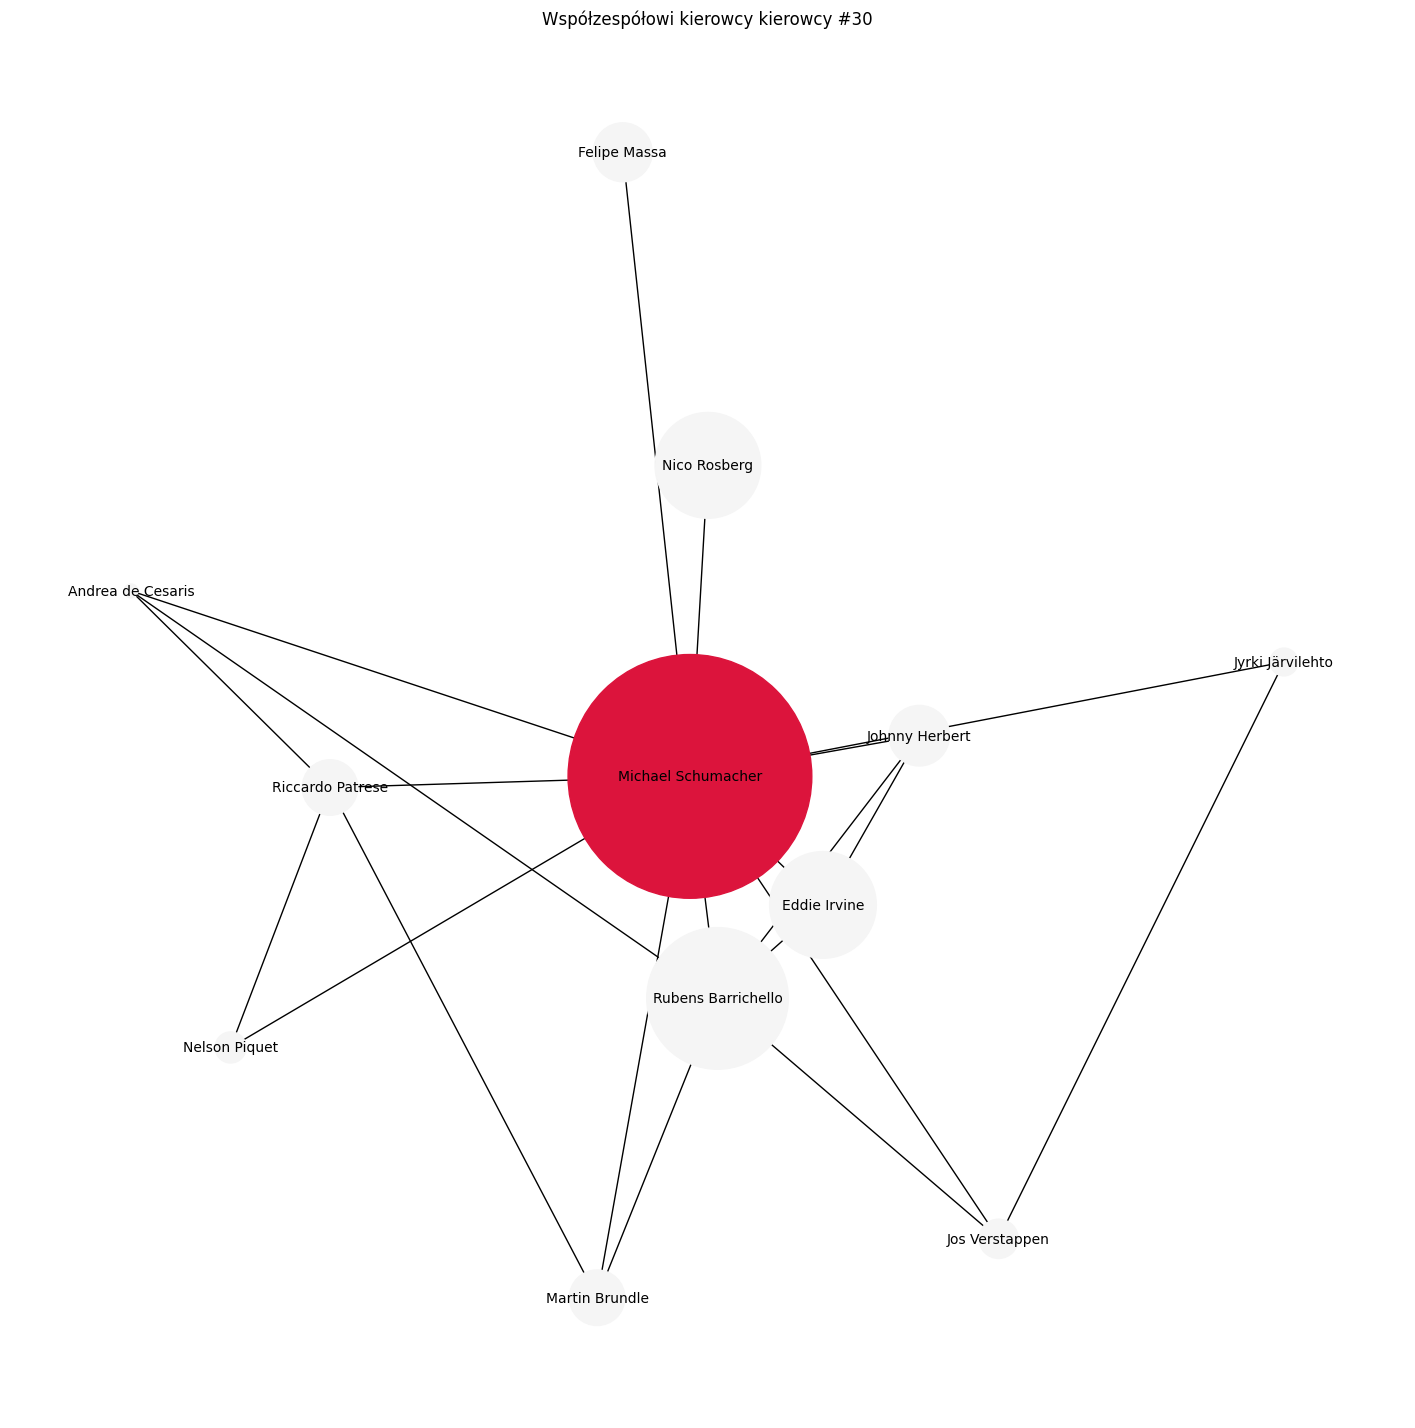

In [116]:
import itertools

# Tworzymy pusty graf nieskierowany
G = nx.Graph()

# Grupuj po numerze wyścigu i numerze zespołu
grouped = results.groupby(['raceId', 'constructorId'])

for _, group in grouped:
    drivers = group['driverId'].tolist()
    # Tworzymy wszystkie pary kierowców z tego samego zespołu w tym wyścigu
    for driver1, driver2 in itertools.combinations(sorted(drivers), 2):
        if G.has_edge(driver1, driver2):
            G[driver1][driver2]['weight'] += 1
        else:
            G.add_edge(driver1, driver2, weight=1)

# Przykład: wypisz wagi krawędzi kierowcy nr 44
for neighbor in G.neighbors(30):
    weight = G[30][neighbor]['weight']
    print(f"Kierowca 30 był w zespole z {neighbor} w {weight} wyścigach.")
# === 2. Stwórz podgraf dla wybranego kierowcy ===
target_driver = 30  # <- tutaj możesz podać dowolny numer kierowcy

# Sąsiedzi (współzespółowi)
neighbors = list(G.neighbors(target_driver))
subgraph_nodes = neighbors + [target_driver]
G_sub = G.subgraph(subgraph_nodes)

# === 3. Oblicz wielkości nodów ===
# Dla głównego kierowcy (proporcjonalnie do liczby wszystkich wyścigów)
target_driver_races = results[results['driverId'] == target_driver]['raceId'].nunique()
node_sizes = {target_driver: target_driver_races * 100}  # Skalowanie wielkości głównego kierowcy

# Dla innych kierowców (proporcjonalnie do liczby wspólnych wyścigów)
for driver in neighbors:
    common_races = G_sub[target_driver][driver]['weight']
    node_sizes[driver] = common_races * 100  # Skalowanie wielkości wierzchołków

labels = {
    node: driver_id_to_name.get(node, str(node))
    for node in G_sub.nodes()
}
node_colors = [
    'crimson' if node == target_driver else 'whitesmoke'
    for node in G_sub.nodes()
]

# === 4. Rysowanie podgrafu ===
pos = nx.spring_layout(G_sub, seed=42)

plt.figure(figsize=(18, 18))

# Rysuj wierzchołki (z odpowiednimi wielkościami)
nx.draw_networkx_nodes(G_sub, pos, node_size=[node_sizes[node] for node in G_sub.nodes()], node_color=node_colors)

# Rysuj etykiety
nx.draw_networkx_labels(G_sub, pos, labels, font_size=10)

# Rysuj krawędzie
nx.draw_networkx_edges(G_sub, pos, width=1)

# Tytuł i wygląd
plt.title(f"Współzespółowi kierowcy kierowcy #{target_driver}")
plt.axis('off')
plt.savefig('13.png', dpi=300, facecolor='gray')
plt.show()